# EDA — Clasificación del nivel de operación aérea mensual por aeropuerto en Colombia

En este notebook se realiza el Análisis Exploratorio de Datos (EDA) sobre el dataset Gold construido en el pipeline de ingesta. El análisis sigue la metodología CRISP-DM y cubre:

0. Imports y configuración
1. Carga del dataset Gold
2. Análisis del target
3. Cobertura temporal y de aeropuertos
4. Variables operacionales
5. Variables de tráfico origen-destino
6. Variables meteorológicas
7. EDA geográfico del dataset mensual aeroportuario
8. Correlaciones con el target


## 0. Imports y configuración

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
import plotly.express as px
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Estilo general de gráficos
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
FIGSIZE_STD  = (12, 5)
FIGSIZE_WIDE = (16, 6)
FIGSIZE_SQ   = (10, 8)

TARGET_COL    = 'target_nivel_operacion_mes_siguiente'
TARGET_ORDER  = ['bajo', 'medio', 'alto']
PALETTE_TARGET = {'bajo': '#4878CF', 'medio': '#6ACC65', 'alto': '#D65F5F'}

spark = (
    SparkSession.builder
    .appName("ProyectoAeropuertosLocal")
    .master("local[*]")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")
spark.conf.set("spark.sql.repl.eagerEval.enabled", True)
spark.conf.set("spark.sql.repl.eagerEval.maxNumRows", 50)

print('Imports OK')


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/28 23:48:14 WARN Utils: Your hostname, madacohe-X532FLC-S532FL, resolves to a loopback address: 127.0.1.1; using 192.168.1.8 instead (on interface wlo1)
26/05/28 23:48:14 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/28 23:48:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Imports OK


## 1. Carga del dataset Gold

In [5]:
BASE_DIR = Path("data_proyecto_aeropuertos")
GOLD_MONTHLY_DIR = BASE_DIR / "gold" / "monthly_airport_dataset"

def read_parquet_pandas(path: Path) -> pd.DataFrame:
    """
    Lee Parquet con pandas.

    Soporta:
    1. Parquet tipo archivo único generado por pandas.
    2. Parquet tipo carpeta generado por Spark:
       archivo.parquet/
       ├── part-00000-...
       ├── part-00001-...
       └── _SUCCESS
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"No existe el path: {path}")

    try:
        return pd.read_parquet(path, engine="pyarrow")
    except Exception as exc:
        print(f"[WARN] pd.read_parquet directo falló: {exc}")
        print("[INFO] Intentando leer part-files internos...")

        part_files = sorted(path.glob("part-*.parquet"))

        if not part_files:
            raise RuntimeError(f"No se encontraron part-files en: {path}")

        return pd.concat(
            [pd.read_parquet(part_file, engine="pyarrow") for part_file in part_files],
            ignore_index=True,
        )


df_full = read_parquet_pandas(
    GOLD_MONTHLY_DIR / "monthly_airport_dataset.parquet"
)

df = read_parquet_pandas(
    GOLD_MONTHLY_DIR / "monthly_airport_model_dataset.parquet"
)

df_full["fecha_mes"] = pd.to_datetime(df_full["fecha_mes"])
df["fecha_mes"] = pd.to_datetime(df["fecha_mes"])

print(f"Dataset completo : {df_full.shape[0]:,} filas x {df_full.shape[1]:,} columnas")
print(f"Dataset modelado : {df.shape[0]:,} filas x {df.shape[1]:,} columnas")
print(f"Período          : {df['fecha_mes'].min().strftime('%Y-%m')} → {df['fecha_mes'].max().strftime('%Y-%m')}")
print(f"Aeropuertos únicos: {df['icao_code'].nunique()}")

Dataset completo : 3,300 filas x 63 columnas
Dataset modelado : 3,254 filas x 66 columnas
Período          : 2020-01 → 2025-11
Aeropuertos únicos: 46


In [6]:
df.head(5)

,icao_code,fecha_mes,operaciones_llegada,operaciones_salida,TOQUE Y DESPEGUE,operaciones_otras,operaciones_total,pasajeros_salida,carga_salida_kg,n_destinos_total,n_empresas_salida,n_registros_salida,pasajeros_llegada,carga_llegada_kg,n_origenes_total,n_empresas_llegada,n_registros_llegada,pasajeros_total,carga_total_kg,pasajeros_salida_internacional,pasajeros_salida_nacional,pasajeros_llegada_internacional,pasajeros_llegada_nacional,pasajeros_internacional_total,proporcion_pasajeros_internacional,n_metar_mes,temp_media_c,temp_min_c,temp_max_c,temp_std_c,dewpoint_media_c,humedad_media_pct,viento_medio_kt,viento_max_kt,viento_std_kt,rafaga_max_kt,visibilidad_media_sm,visibilidad_min_sm,visibilidad_std_sm,cloud_base_min_ft,altimeter_media_inhg,prop_lluvia,prop_tormenta,prop_niebla,prop_baja_visibilidad,prop_viento_fuerte,prop_rafaga,prop_ifr_aprox,n_metar_esperados_mes,cobertura_metar_ratio,name,type,municipality,region_name,iata_code,latitude_deg,longitude_deg,elevation_ft,scheduled_service,tiene_metar_mes,tiene_od_mes,sin_od_sin_metar_mes,target_operaciones_total_mes_siguiente,target_q33_operaciones,target_q66_operaciones,target_nivel_operacion_mes_siguiente
0,SKAR,2020-01-01,408.00,409.00,0.00,0.00,817.00,"25,548.00",119.00,73,5,85,"22,854.00",0.00,71,5,85,"48,402.00",119.00,"4,448.00","21,100.00","3,880.00","18,974.00","8,328.00",0.17,573,23.65,15.00,33.00,4.33,18.79,76.98,1.20,12.00,1.98,NaN,5.81,0.62,1.06,600.00,30.04,0.11,0.01,0.05,0.05,0.00,0.00,0.05,744.00,0.77,El Eden Airport,medium_airport,Armenia,Quindio Department,AXM,4.45278,-75.7664,3990,1,1,1,0,744.00,220.00,564.00,alto
1,SKAR,2020-02-01,372.00,372.00,0.00,0.00,744.00,"22,490.00",182.00,66,6,76,"22,022.00",130.00,71,6,82,"44,512.00",312.00,"3,206.00","19,284.00","2,930.00","19,092.00","6,136.00",0.14,508,23.82,16.00,34.00,4.36,18.88,76.77,1.27,13.00,2.05,NaN,5.63,0.19,1.31,300.00,30.02,0.13,0.03,0.10,0.06,0.00,0.00,0.07,696.00,0.73,El Eden Airport,medium_airport,Armenia,Quindio Department,AXM,4.45278,-75.7664,3990,1,1,1,0,531.00,220.00,564.00,medio
2,SKAR,2020-03-01,265.00,266.00,0.00,0.00,531.00,"13,541.00","4,170.00",69,7,82,"13,241.00","3,660.00",67,7,87,"26,782.00","7,830.00","1,975.00","11,566.00","1,580.00","11,661.00","3,555.00",0.13,525,23.27,15.00,30.00,3.24,18.00,74.21,1.55,14.00,2.32,NaN,5.67,0.12,1.17,800.00,30.03,0.12,0.02,0.12,0.06,0.00,0.00,0.07,744.00,0.71,El Eden Airport,medium_airport,Armenia,Quindio Department,AXM,4.45278,-75.7664,3990,1,1,1,0,21.00,220.00,564.00,bajo
3,SKAR,2020-04-01,11.00,10.00,0.00,0.00,21.00,0.00,"17,216.00",3,1,3,0.00,"16,709.00",2,1,2,0.00,"33,925.00",0.00,0.00,0.00,0.00,0.00,0.00,277,24.25,18.00,31.00,3.15,19.52,76.48,1.74,9.00,2.36,NaN,5.64,0.19,1.30,200.00,30.07,0.17,0.04,0.06,0.05,0.00,0.00,0.08,720.00,0.38,El Eden Airport,medium_airport,Armenia,Quindio Department,AXM,4.45278,-75.7664,3990,1,1,1,0,31.00,220.00,564.00,bajo
4,SKAR,2020-05-01,18.00,13.00,0.00,0.00,31.00,0.00,"7,891.00",2,2,2,0.00,"6,061.00",2,2,2,0.00,"13,952.00",0.00,0.00,0.00,0.00,0.00,0.00,208,25.41,20.00,32.00,2.79,20.29,74.47,1.33,8.00,1.97,NaN,5.91,1.24,0.89,800.00,30.07,0.12,0.00,0.06,0.03,0.00,0.00,0.04,744.00,0.28,El Eden Airport,medium_airport,Armenia,Quindio Department,AXM,4.45278,-75.7664,3990,1,1,1,0,12.00,220.00,564.00,bajo


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3254 entries, 0 to 3253
Data columns (total 66 columns):
 #   Column                                  Non-Null Count  Dtype        
---  ------                                  --------------  -----        
 0   icao_code                               3254 non-null   str          
 1   fecha_mes                               3254 non-null   datetime64[s]
 2   operaciones_llegada                     3254 non-null   float64      
 3   operaciones_salida                      3254 non-null   float64      
 4   TOQUE Y DESPEGUE                        3254 non-null   float64      
 5   operaciones_otras                       3254 non-null   float64      
 6   operaciones_total                       3254 non-null   float64      
 7   pasajeros_salida                        3254 non-null   float64      
 8   carga_salida_kg                         3254 non-null   float64      
 9   n_destinos_total                        3254 non-null   int64        
 10 

In [8]:
cols_desc = [
    'operaciones_total', 'operaciones_llegada', 'operaciones_salida',
    'pasajeros_total', 'carga_total_kg',
    'temp_media_c', 'humedad_media_pct', 'viento_medio_kt',
    'visibilidad_media_sm', 'prop_lluvia', 'prop_tormenta',
    'target_operaciones_total_mes_siguiente'
]
df[cols_desc].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
operaciones_total,"3,254.00","1,474.92","3,905.57",1.00,198.00,464.50,"1,094.50","32,767.00"
operaciones_llegada,"3,254.00",727.22,"1,955.77",0.00,97.00,215.00,518.00,"16,373.00"
operaciones_salida,"3,254.00",727.16,"1,952.38",0.00,98.00,218.00,516.00,"16,394.00"
pasajeros_total,"3,254.00","124,075.71","398,143.63",0.00,"2,614.00","11,578.50","57,842.25","3,552,349.00"
carga_total_kg,"3,254.00","1,796,552.81","9,109,196.47",0.00,"2,233.00","39,169.50","216,618.00","76,516,003.00"
temp_media_c,"2,440.00",25.16,4.68,9.00,23.00,26.62,28.42,35.00
humedad_media_pct,"2,436.00",77.94,10.10,35.32,72.85,79.44,84.49,100.00
viento_medio_kt,"2,442.00",4.76,2.39,0.00,3.26,4.38,5.65,16.00
visibilidad_media_sm,"2,442.00",5.81,0.60,0.06,5.71,6.01,6.14,6.21
prop_lluvia,"2,444.00",0.13,0.15,0.00,0.03,0.09,0.17,1.00


## 2. Análisis del target

### 2.1 Distribución de clases

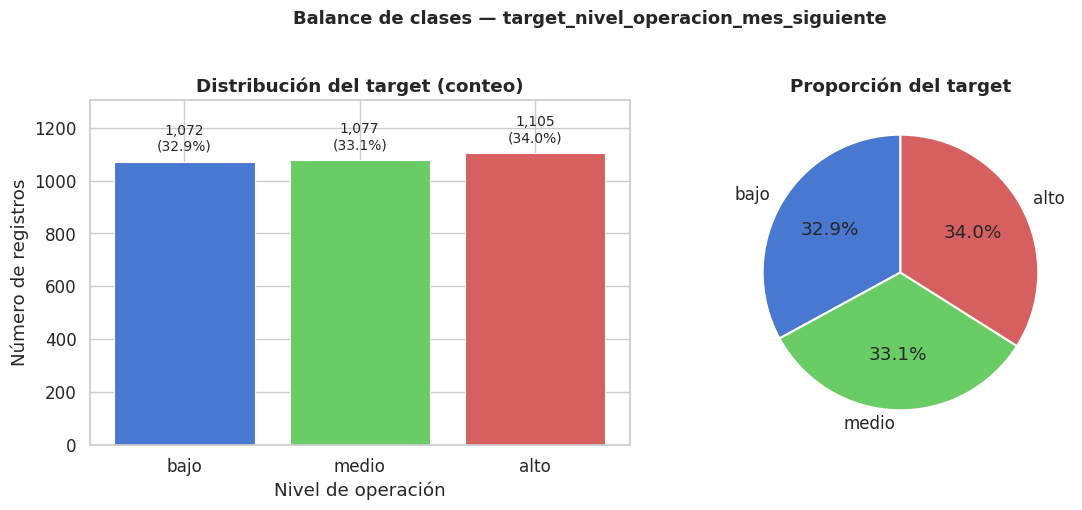


Balance de clases:
                                         n     %
target_nivel_operacion_mes_siguiente            
bajo                                  1072 32.90
medio                                 1077 33.10
alto                                  1105 34.00


In [9]:
conteo_target = df[TARGET_COL].value_counts().reindex(TARGET_ORDER)
pct_target    = (conteo_target / conteo_target.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_STD)

axes[0].bar(TARGET_ORDER, conteo_target.values,
            color=[PALETTE_TARGET[c] for c in TARGET_ORDER], edgecolor='white', linewidth=0.8)
for i, (n, p) in enumerate(zip(conteo_target.values, pct_target.values)):
    axes[0].text(i, n + 30, f'{n:,}\n({p}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Distribución del target (conteo)', fontweight='bold')
axes[0].set_xlabel('Nivel de operación')
axes[0].set_ylabel('Número de registros')
axes[0].set_ylim(0, conteo_target.max() * 1.18)

axes[1].pie(conteo_target.values, labels=TARGET_ORDER, autopct='%1.1f%%',
            colors=[PALETTE_TARGET[c] for c in TARGET_ORDER],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporción del target', fontweight='bold')

plt.suptitle('Balance de clases — target_nivel_operacion_mes_siguiente',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nBalance de clases:')
print(pd.DataFrame({'n': conteo_target, '%': pct_target}))


### 2.2 Distribución numérica del target + umbrales

/tmp/ipykernel_43063/2091902545.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_class, labels=TARGET_ORDER, patch_artist=True,


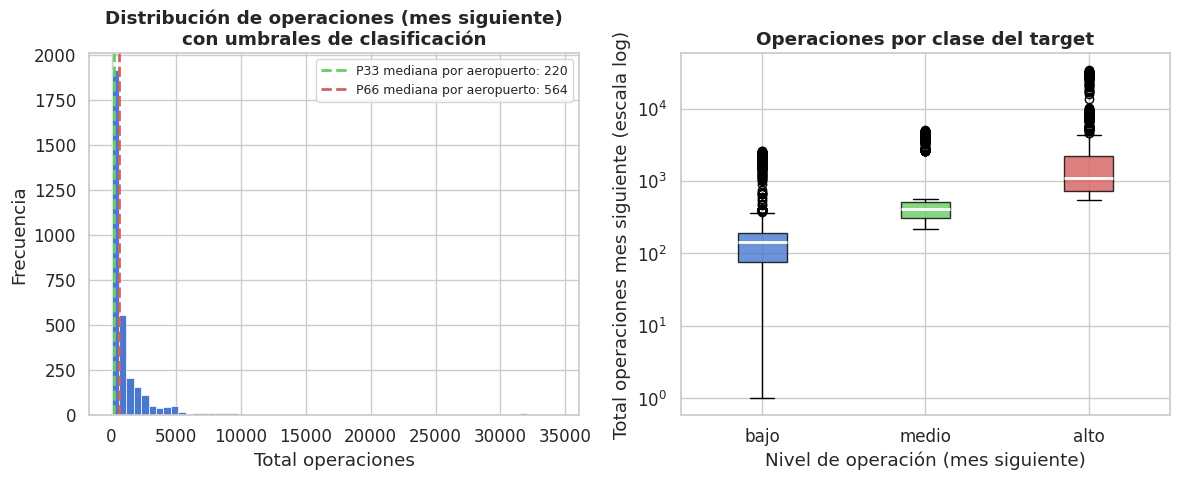

Umbral bajo  → medio : 220 operaciones (mediana por aeropuerto)
Umbral medio → alto  : 564 operaciones (mediana por aeropuerto)

Rango P33 por aeropuerto: 220 — 2,564
Rango P66 por aeropuerto: 539 — 4,971

Balance de clases:
target_nivel_operacion_mes_siguiente
bajo     1072
medio    1077
alto     1105
Name: count, dtype: int64


In [10]:
# Umbrales son POR AEROPUERTO — se muestra la mediana como referencia visual
q33_mediana = df['target_q33_operaciones'].median()
q66_mediana = df['target_q66_operaciones'].median()

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_STD)

# Histograma con umbrales de referencia
axes[0].hist(df['target_operaciones_total_mes_siguiente'].dropna(),
             bins=60, color='#4878CF', edgecolor='white', linewidth=0.5)
axes[0].axvline(q33_mediana, color='#6ACC65', linestyle='--', linewidth=2,
                label=f'P33 mediana por aeropuerto: {q33_mediana:,.0f}')
axes[0].axvline(q66_mediana, color='#D65F5F', linestyle='--', linewidth=2,
                label=f'P66 mediana por aeropuerto: {q66_mediana:,.0f}')
axes[0].set_title('Distribución de operaciones (mes siguiente)\ncon umbrales de clasificación',
                  fontweight='bold')
axes[0].set_xlabel('Total operaciones')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=9)

# Boxplot por clase con escala logarítmica
data_by_class = [
    df[df[TARGET_COL] == c]['target_operaciones_total_mes_siguiente'].dropna().values
    for c in TARGET_ORDER
]
bp = axes[1].boxplot(data_by_class, labels=TARGET_ORDER, patch_artist=True,
                     medianprops={'color': 'white', 'linewidth': 2})
for patch, color in zip(bp['boxes'], [PALETTE_TARGET[c] for c in TARGET_ORDER]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

axes[1].set_yscale('log')  # ← escala log para separar las cajas
axes[1].set_title('Operaciones por clase del target', fontweight='bold')
axes[1].set_xlabel('Nivel de operación (mes siguiente)')
axes[1].set_ylabel('Total operaciones mes siguiente (escala log)')

plt.tight_layout()
plt.show()

print(f'Umbral bajo  → medio : {q33_mediana:,.0f} operaciones (mediana por aeropuerto)')
print(f'Umbral medio → alto  : {q66_mediana:,.0f} operaciones (mediana por aeropuerto)')
print(f'\nRango P33 por aeropuerto: {df["target_q33_operaciones"].min():,.0f} — {df["target_q33_operaciones"].max():,.0f}')
print(f'Rango P66 por aeropuerto: {df["target_q66_operaciones"].min():,.0f} — {df["target_q66_operaciones"].max():,.0f}')
print(f'\nBalance de clases:')
print(df[TARGET_COL].value_counts().reindex(TARGET_ORDER))


## 3. Cobertura temporal y de aeropuertos

### 3.1 Aeropuertos por tipo

In [11]:
tipo_counts = df.drop_duplicates('icao_code')['type'].value_counts()
print('Aeropuertos únicos en el dataset de modelado:')
print(tipo_counts.to_string())
print(f'\nTotal: {df["icao_code"].nunique()} aeropuertos')


Aeropuertos únicos en el dataset de modelado:
type
medium_airport    38
large_airport      6
small_airport      2

Total: 46 aeropuertos


### 3.2 Heatmap cobertura temporal — Top 40 aeropuertos

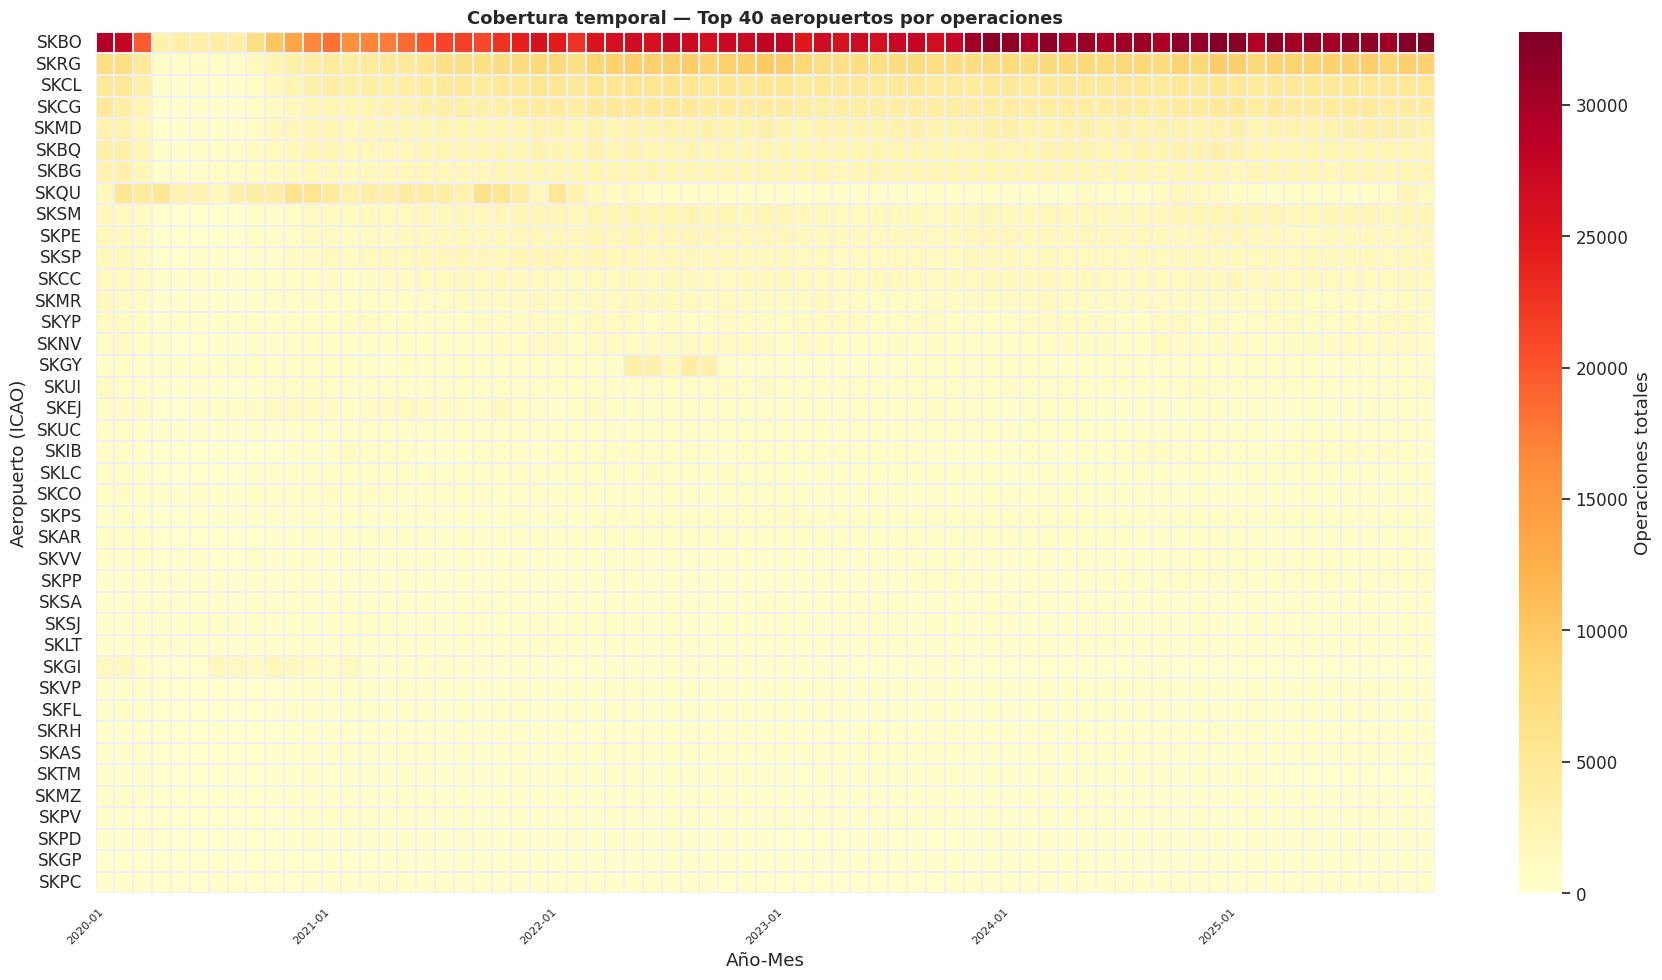

In [12]:

top_icaos = (df.groupby('icao_code')['operaciones_total']
               .sum().nlargest(40).index.tolist())

pivot_cob = (
    df[df['icao_code'].isin(top_icaos)]
    .assign(anio_mes=lambda x: x['fecha_mes'].dt.to_period('M').astype(str))
    .pivot_table(index='icao_code', columns='anio_mes',
                 values='operaciones_total', aggfunc='sum')
    .fillna(0)
    .loc[top_icaos]
)

fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(pivot_cob, cmap='YlOrRd', linewidths=0.3, linecolor='#f0f0f0',
            ax=ax, cbar_kws={'label': 'Operaciones totales'})
ax.set_title('Cobertura temporal — Top 40 aeropuertos por operaciones',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Año-Mes')
ax.set_ylabel('Aeropuerto (ICAO)')
for i, label in enumerate(ax.get_xticklabels()):
    if i % 6 != 0:
        label.set_visible(False)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


### 3.3 Registros por año

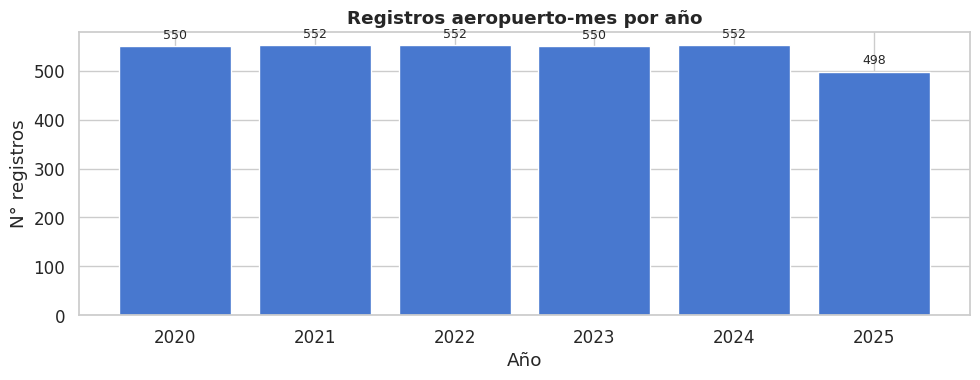

In [13]:
registros_anio = df.groupby(df['fecha_mes'].dt.year).size().reset_index(name='n_registros')
registros_anio.columns = ['anio', 'n_registros']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(registros_anio['anio'].astype(str), registros_anio['n_registros'],
       color='#4878CF', edgecolor='white')
for idx, (_, row) in enumerate(registros_anio.iterrows()):
    ax.text(idx, row['n_registros'] + 10, f"{row['n_registros']:,}",
            ha='center', va='bottom', fontsize=9)
ax.set_title('Registros aeropuerto-mes por año', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('N° registros')
plt.tight_layout()
plt.show()


### 3.4 Distribución del target por año (¿se mantiene el balance?)

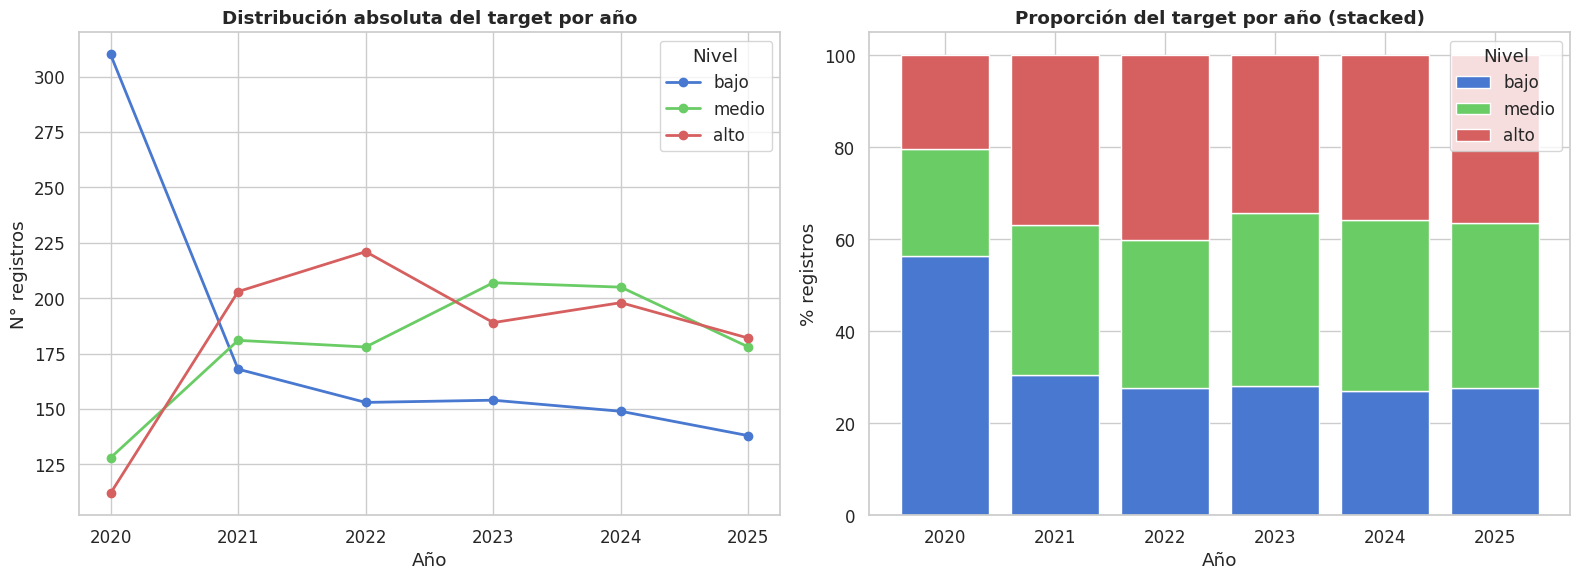

In [14]:
target_anio = (
    df.assign(anio=df['fecha_mes'].dt.year)
    .groupby(['anio', TARGET_COL])
    .size()
    .reset_index(name='n')
)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Absoluto
for nivel in TARGET_ORDER:
    sub = target_anio[target_anio[TARGET_COL] == nivel]
    axes[0].plot(sub['anio'], sub['n'], marker='o', label=nivel,
                color=PALETTE_TARGET[nivel], linewidth=2)
axes[0].set_title('Distribución absoluta del target por año', fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('N° registros')
axes[0].legend(title='Nivel')
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))

# Proporcional — para ver si el balance se mantiene
target_anio_pct = (
    target_anio.copy()
    .assign(total=lambda d: d.groupby('anio')['n'].transform('sum'))
    .assign(pct=lambda d: d['n'] / d['total'] * 100)
)
bottom = np.zeros(target_anio_pct['anio'].nunique())
anios  = sorted(target_anio_pct['anio'].unique())
x      = np.arange(len(anios))
for nivel in TARGET_ORDER:
    vals = []
    for a in anios:
        sub = target_anio_pct[
            (target_anio_pct['anio'] == a) &
            (target_anio_pct[TARGET_COL] == nivel)
        ]['pct'].values
        vals.append(sub[0] if len(sub) > 0 else 0.0)
    axes[1].bar(x, vals, bottom=bottom, label=nivel,
                color=PALETTE_TARGET[nivel], edgecolor='white')
    bottom += np.array(vals)
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(a) for a in anios])
axes[1].set_title('Proporción del target por año (stacked)', fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('% registros')
axes[1].legend(title='Nivel')

plt.tight_layout()
plt.show()


## 4. Variables operacionales

### 4.1 Top 15 aeropuertos por operaciones totales acumuladas 


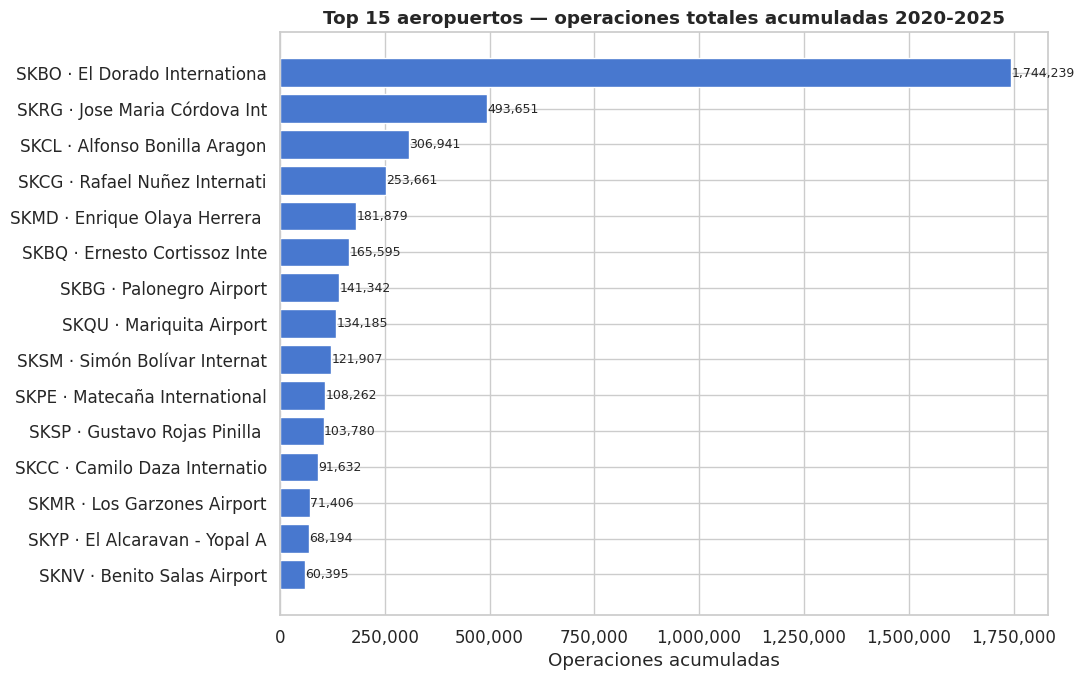

In [15]:
top15_ops  = (df.groupby('icao_code')['operaciones_total']
                .sum().nlargest(15).sort_values(ascending=True))
nombre_map = df.drop_duplicates('icao_code').set_index('icao_code')['name'].to_dict()
labels     = [f"{icao} · {str(nombre_map.get(icao, ''))[:22]}" for icao in top15_ops.index]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(labels, top15_ops.values, color='#4878CF', edgecolor='white')
for bar, val in zip(bars, top15_ops.values):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=9)
ax.set_title('Top 15 aeropuertos — operaciones totales acumuladas 2020-2025',
             fontweight='bold')
ax.set_xlabel('Operaciones acumuladas')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()


###  4.2 Evolución mensual total + impacto COVID 

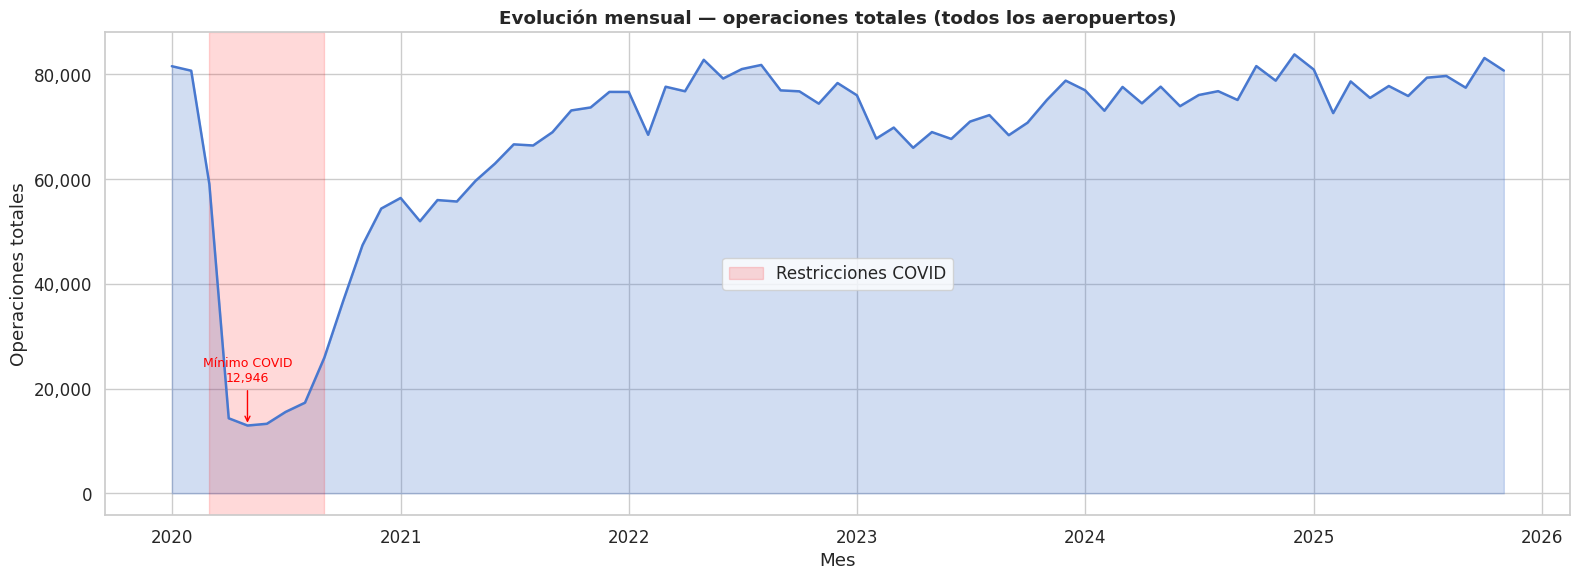

In [16]:
ops_tiempo = df.groupby('fecha_mes')['operaciones_total'].sum().reset_index()

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
ax.fill_between(ops_tiempo['fecha_mes'], ops_tiempo['operaciones_total'],
                alpha=0.25, color='#4878CF')
ax.plot(ops_tiempo['fecha_mes'], ops_tiempo['operaciones_total'],
        color='#4878CF', linewidth=1.8)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-09-01'),
           alpha=0.15, color='red', label='Restricciones COVID')
# Anotar el mínimo
min_idx = ops_tiempo['operaciones_total'].idxmin()
min_row = ops_tiempo.loc[min_idx]
ax.annotate(f"Mínimo COVID\n{min_row['operaciones_total']:,.0f}",
            xy=(min_row['fecha_mes'], min_row['operaciones_total']),
            xytext=(min_row['fecha_mes'], min_row['operaciones_total'] + ops_tiempo['operaciones_total'].max()*0.1),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9, ha='center')
ax.set_title('Evolución mensual — operaciones totales (todos los aeropuertos)',
             fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Operaciones totales')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()


###  4.3 Distribución de operaciones_total por clase del target 

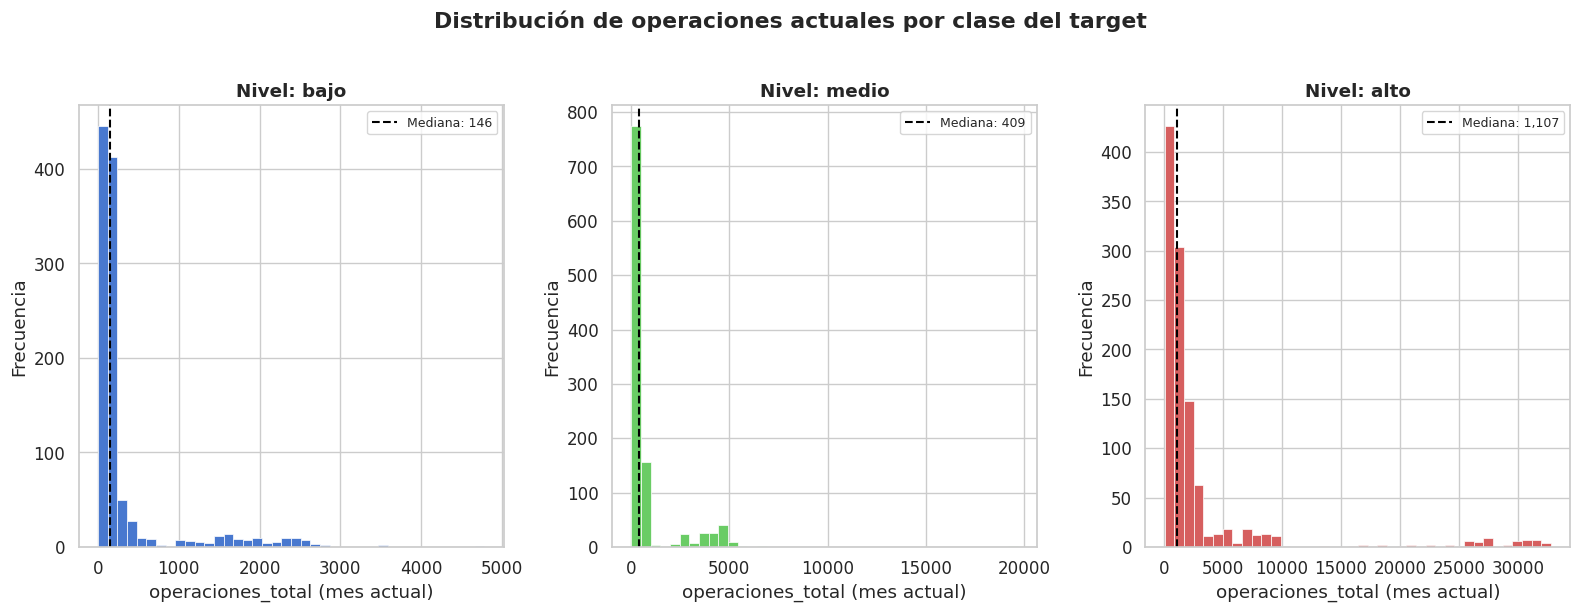

In [17]:
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_WIDE, sharey=False)
for ax, nivel in zip(axes, TARGET_ORDER):
    datos = df[df[TARGET_COL] == nivel]['operaciones_total']
    ax.hist(datos, bins=40, color=PALETTE_TARGET[nivel], edgecolor='white', linewidth=0.5)
    ax.set_title(f'Nivel: {nivel}', fontweight='bold')
    ax.set_xlabel('operaciones_total (mes actual)')
    ax.set_ylabel('Frecuencia')
    ax.axvline(datos.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mediana: {datos.median():,.0f}')
    ax.legend(fontsize=9)
plt.suptitle('Distribución de operaciones actuales por clase del target',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


###  4.4 Proporción llegadas vs salidas + concentración por aeropuerto 

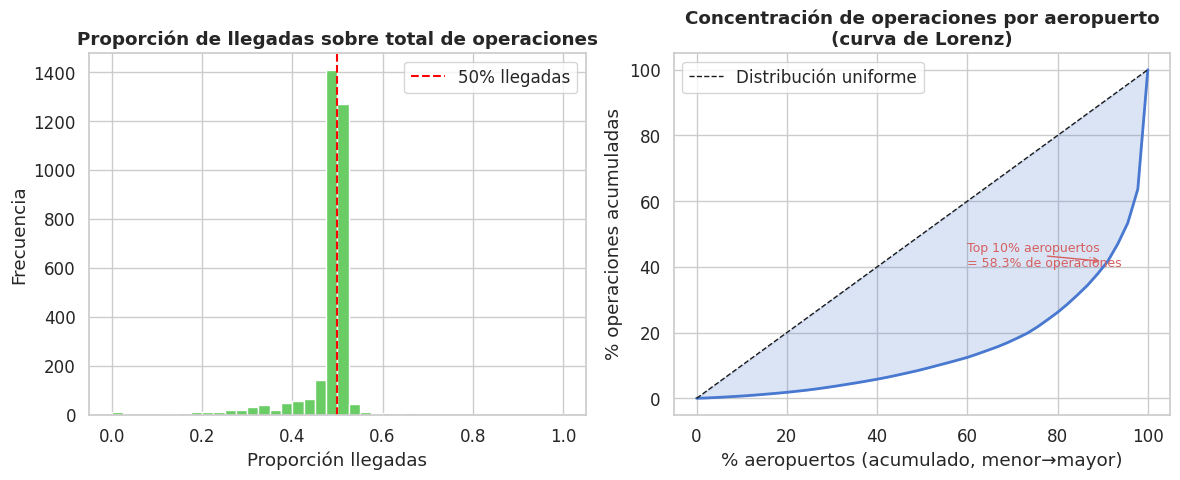

Mediana proporción llegadas: 0.499


In [18]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_STD)

df_ops = df.copy()
df_ops['prop_llegadas'] = df_ops['operaciones_llegada'] / (df_ops['operaciones_total'] + 1e-9)

axes[0].hist(df_ops['prop_llegadas'], bins=40, color='#6ACC65', edgecolor='white')
axes[0].axvline(0.5, color='red', linestyle='--', label='50% llegadas')
axes[0].set_title('Proporción de llegadas sobre total de operaciones', fontweight='bold')
axes[0].set_xlabel('Proporción llegadas')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Curva de Lorenz-style: concentración de operaciones por aeropuerto
ops_por_aeropuerto = df.groupby('icao_code')['operaciones_total'].sum().sort_values()
total = ops_por_aeropuerto.sum()
cumsum = ops_por_aeropuerto.cumsum() / total * 100
x_pct  = np.linspace(0, 100, len(cumsum))
axes[1].plot(x_pct, cumsum.values, color='#4878CF', linewidth=2)
axes[1].plot([0, 100], [0, 100], 'k--', linewidth=1, label='Distribución uniforme')
axes[1].fill_between(x_pct, cumsum.values, x_pct, alpha=0.2, color='#4878CF')
axes[1].set_title('Concentración de operaciones por aeropuerto\n(curva de Lorenz)', fontweight='bold')
axes[1].set_xlabel('% aeropuertos (acumulado, menor→mayor)')
axes[1].set_ylabel('% operaciones acumuladas')
axes[1].legend()

# Mostrar % que concentra el top 10%
top10_idx = int(len(ops_por_aeropuerto) * 0.9)
pct_top10 = 100 - cumsum.iloc[top10_idx]
axes[1].annotate(f'Top 10% aeropuertos\n= {pct_top10:.1f}% de operaciones',
                 xy=(90, cumsum.iloc[top10_idx]), xytext=(60, 40),
                 arrowprops=dict(arrowstyle='->', color='#D65F5F'), color='#D65F5F', fontsize=9)
plt.tight_layout()
plt.show()
print(f'Mediana proporción llegadas: {df_ops["prop_llegadas"].median():.3f}')


## 5. Variables de tráfico origen-destino

###  5.1 Pasajeros totales: evolución mensual 


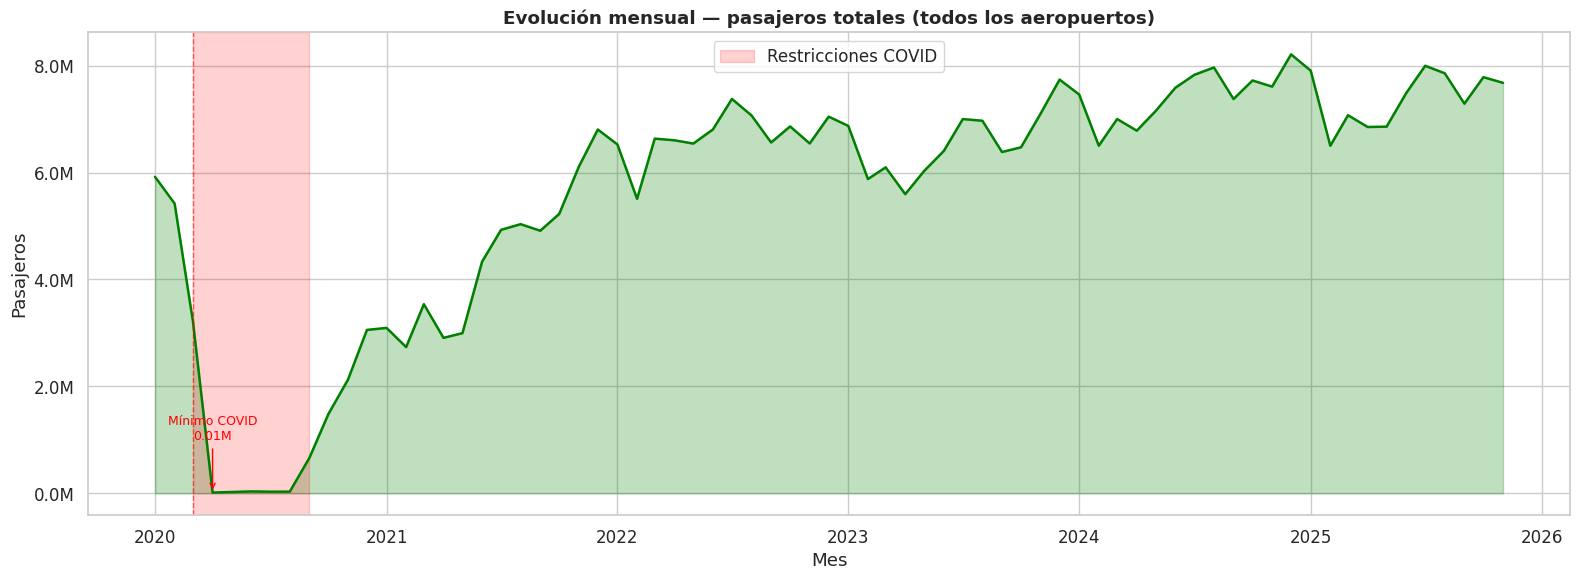

In [19]:
pax_tiempo = df.groupby('fecha_mes')['pasajeros_total'].sum().reset_index()

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
ax.fill_between(pax_tiempo['fecha_mes'], pax_tiempo['pasajeros_total'],
                alpha=0.25, color='green')
ax.plot(pax_tiempo['fecha_mes'], pax_tiempo['pasajeros_total'],
        color='green', linewidth=1.8)

# Marca COVID
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-09-01'),
           alpha=0.18, color='red', label='Restricciones COVID')
ax.axvline(pd.Timestamp('2020-03-01'), color='red', linewidth=1, linestyle='--', alpha=0.6)

# Anotación en el mínimo
min_idx = pax_tiempo['pasajeros_total'].idxmin()
min_row = pax_tiempo.loc[min_idx]
max_val = pax_tiempo['pasajeros_total'].max()
ax.annotate(f"Mínimo COVID\n{min_row['pasajeros_total']/1e6:.2f}M",
            xy=(min_row['fecha_mes'], min_row['pasajeros_total']),
            xytext=(min_row['fecha_mes'], min_row['pasajeros_total'] + max_val * 0.12),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9, ha='center')

ax.set_title('Evolución mensual — pasajeros totales (todos los aeropuertos)', fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Pasajeros')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend()
plt.tight_layout()
plt.show()


###  5.2 Pasajeros y conectividad por clase del target 


/tmp/ipykernel_43063/2754013643.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_c, labels=TARGET_ORDER, patch_artist=True,
/tmp/ipykernel_43063/2754013643.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_c, labels=TARGET_ORDER, patch_artist=True,


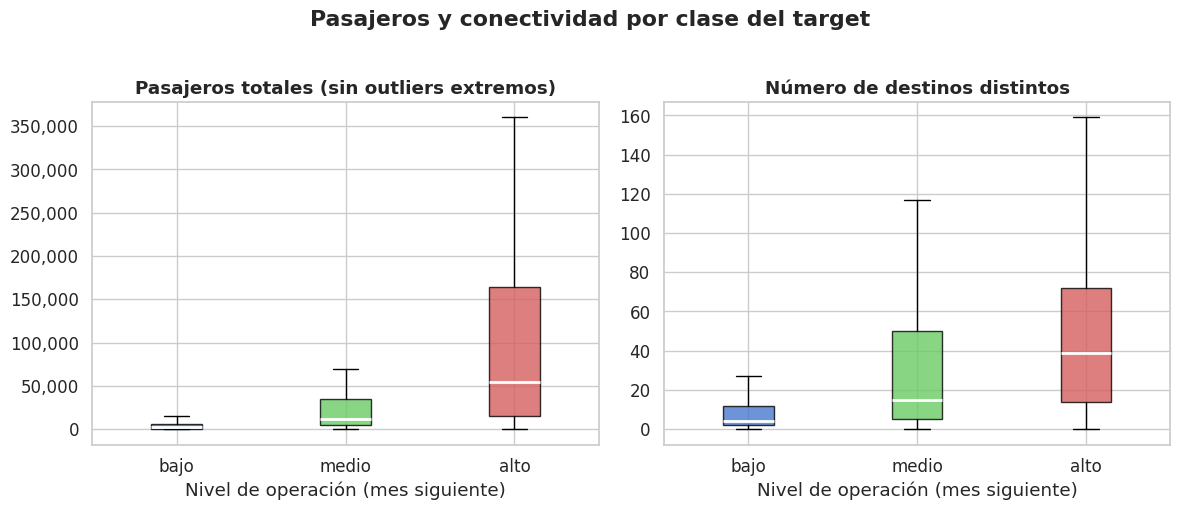

In [20]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_STD)

for ax, col, titulo in zip(axes,
    ['pasajeros_total', 'n_destinos_total'],
    ['Pasajeros totales (sin outliers extremos)', 'Número de destinos distintos']):
    data_by_c = [df[df[TARGET_COL] == c][col].dropna().values for c in TARGET_ORDER]
    bp = ax.boxplot(data_by_c, labels=TARGET_ORDER, patch_artist=True,
                    medianprops={'color': 'white', 'linewidth': 2}, showfliers=False)
    for patch, color in zip(bp['boxes'], [PALETTE_TARGET[c] for c in TARGET_ORDER]):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Nivel de operación (mes siguiente)')

axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.suptitle('Pasajeros y conectividad por clase del target', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


###  5.3 Proporción de pasajeros internacionales 


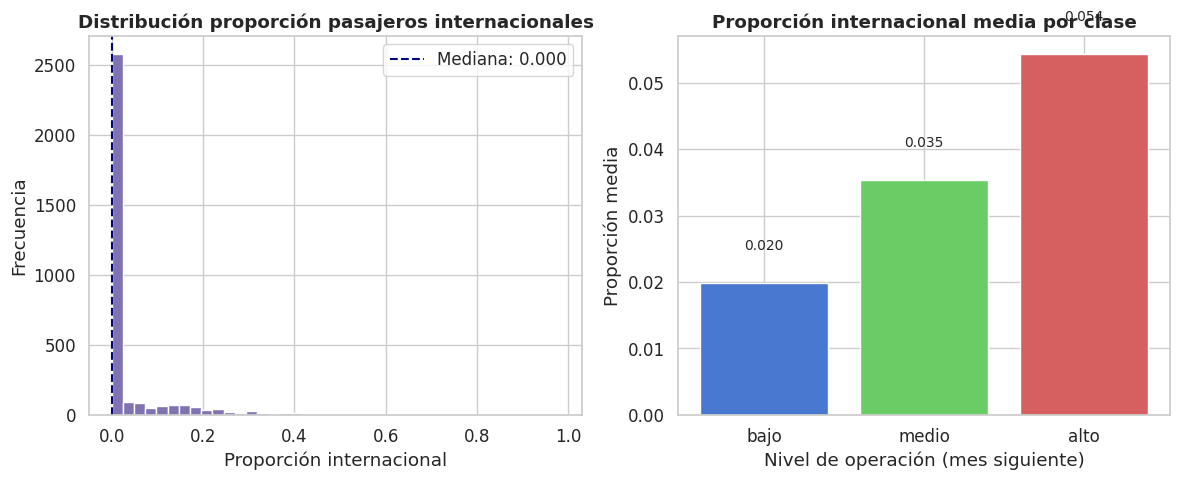

In [21]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_STD)

axes[0].hist(df['proporcion_pasajeros_internacional'].dropna(),
             bins=40, color='#8172B2', edgecolor='white')
axes[0].set_title('Distribución proporción pasajeros internacionales', fontweight='bold')
axes[0].set_xlabel('Proporción internacional')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['proporcion_pasajeros_internacional'].median(), color='navy',
                linestyle='--', label=f'Mediana: {df["proporcion_pasajeros_internacional"].median():.3f}')
axes[0].legend()

medias = df.groupby(TARGET_COL)['proporcion_pasajeros_internacional'].mean().reindex(TARGET_ORDER)
axes[1].bar(TARGET_ORDER, medias.values,
            color=[PALETTE_TARGET[c] for c in TARGET_ORDER], edgecolor='white')
axes[1].set_title('Proporción internacional media por clase', fontweight='bold')
axes[1].set_xlabel('Nivel de operación (mes siguiente)')
axes[1].set_ylabel('Proporción media')
for i, v in enumerate(medias.values):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


## 6. Variables meteorológicas

###  6.1 Cobertura METAR — 3 grupos visualizados explícitamente 


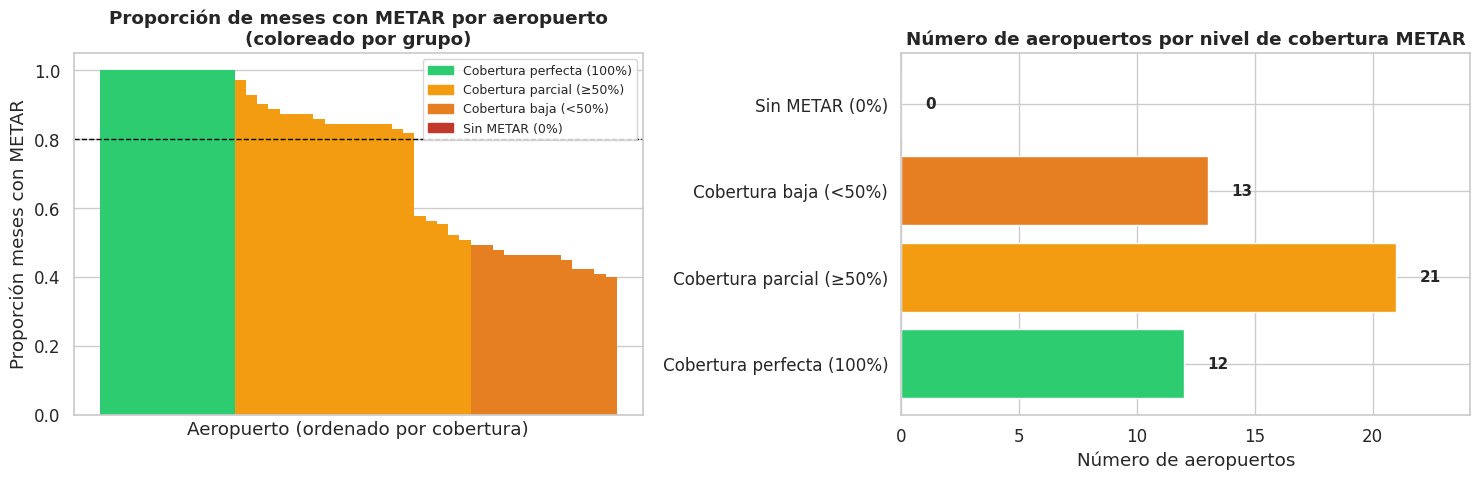

Aeropuertos con al menos 1 mes con METAR : 46 / 46
Aeropuertos con cobertura perfecta (100%): 12
Sin ningún mes con METAR                 : 0


In [22]:
cobertura_metar = (
    df.groupby('icao_code')['tiene_metar_mes']
    .mean()
    .sort_values(ascending=False)
)

# Definir grupos
def grupo_metar(p):
    if p == 1.0: return 'Cobertura perfecta (100%)'
    elif p >= 0.5: return 'Cobertura parcial (≥50%)'
    elif p > 0.0:  return 'Cobertura baja (<50%)'
    else:          return 'Sin METAR (0%)'

grupo_colors = {
    'Cobertura perfecta (100%)':  '#2ecc71',
    'Cobertura parcial (≥50%)':   '#f39c12',
    'Cobertura baja (<50%)':      '#e67e22',
    'Sin METAR (0%)':             '#c0392b',
}

grupos = cobertura_metar.apply(grupo_metar)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Barras individuales coloreadas por grupo
bar_colors = [grupo_colors[grupos[icao]] for icao in cobertura_metar.index]
axes[0].bar(range(len(cobertura_metar)), cobertura_metar.values,
            color=bar_colors, edgecolor='none', width=1.0)
axes[0].axhline(0.8, color='black', linestyle='--', linewidth=1, label='Umbral 80%')
axes[0].set_title('Proporción de meses con METAR por aeropuerto\n(coloreado por grupo)',
                  fontweight='bold')
axes[0].set_xlabel('Aeropuerto (ordenado por cobertura)')
axes[0].set_ylabel('Proporción meses con METAR')
axes[0].set_xticks([])
patches = [mpatches.Patch(color=c, label=l) for l, c in grupo_colors.items()]
axes[0].legend(handles=patches, fontsize=9)

# Conteo por grupo
conteo_grupos = grupos.value_counts()
order_grupos  = list(grupo_colors.keys())
conteo_plot   = [conteo_grupos.get(g, 0) for g in order_grupos]
bars = axes[1].barh(order_grupos, conteo_plot,
                    color=[grupo_colors[g] for g in order_grupos], edgecolor='white')
for bar, val in zip(bars, conteo_plot):
    axes[1].text(val + 1, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=11, fontweight='bold')
axes[1].set_title('Número de aeropuertos por nivel de cobertura METAR',
                  fontweight='bold')
axes[1].set_xlabel('Número de aeropuertos')
axes[1].set_xlim(0, max(conteo_plot) * 1.15)

plt.tight_layout()
plt.show()

n_con_metar = (cobertura_metar > 0).sum()
print(f'Aeropuertos con al menos 1 mes con METAR : {n_con_metar} / {len(cobertura_metar)}')
print(f'Aeropuertos con cobertura perfecta (100%): {(cobertura_metar == 1.0).sum()}')
print(f'Sin ningún mes con METAR                 : {(cobertura_metar == 0).sum()}')


###  6.2 Distribuciones de variables meteorológicas clave 


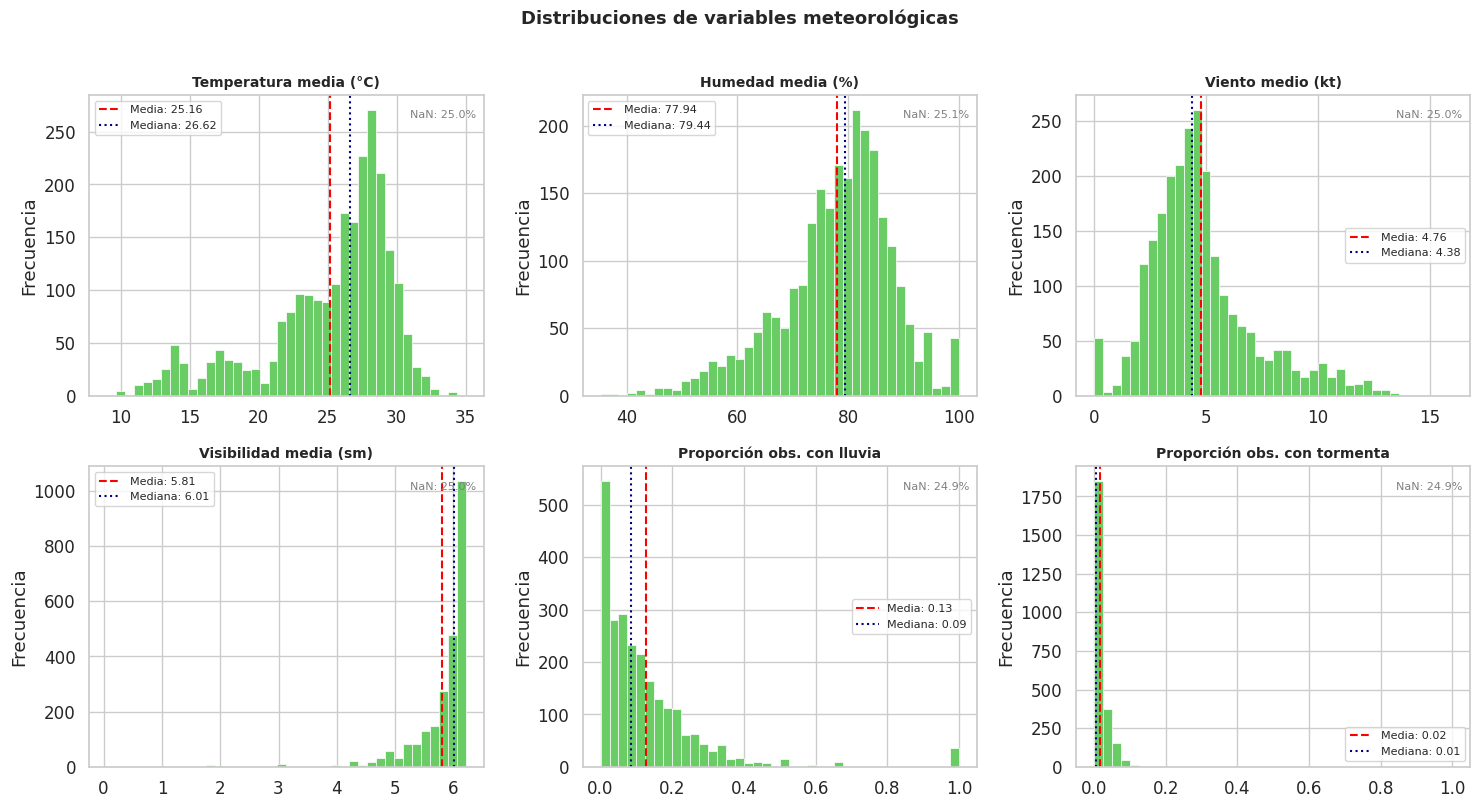

In [23]:
vars_meteo = [
    ('temp_media_c',         'Temperatura media (°C)'),
    ('humedad_media_pct',    'Humedad media (%)'),
    ('viento_medio_kt',      'Viento medio (kt)'),
    ('visibilidad_media_sm', 'Visibilidad media (sm)'),
    ('prop_lluvia',          'Proporción obs. con lluvia'),
    ('prop_tormenta',        'Proporción obs. con tormenta'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (col, label) in zip(axes.flatten(), vars_meteo):
    data = df[col].dropna()
    ax.hist(data, bins=40, color='#6ACC65', edgecolor='white', linewidth=0.5)
    ax.axvline(data.mean(),   color='red',  linestyle='--', linewidth=1.5,
               label=f'Media: {data.mean():.2f}')
    ax.axvline(data.median(), color='navy', linestyle=':',  linewidth=1.5,
               label=f'Mediana: {data.median():.2f}')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylabel('Frecuencia')
    # Porcentaje de nulos
    pct_null = df[col].isnull().mean() * 100
    ax.text(0.98, 0.95, f'NaN: {pct_null:.1f}%', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='gray')

plt.suptitle('Distribuciones de variables meteorológicas', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


###  6.3 Variables meteorológicas por clase del target 


/tmp/ipykernel_43063/1190146285.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_c, labels=TARGET_ORDER, patch_artist=True,
/tmp/ipykernel_43063/1190146285.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_c, labels=TARGET_ORDER, patch_artist=True,
/tmp/ipykernel_43063/1190146285.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_c, labels=TARGET_ORDER, patch_artist=True,
/tmp/ipykernel_43063/1190146285.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the

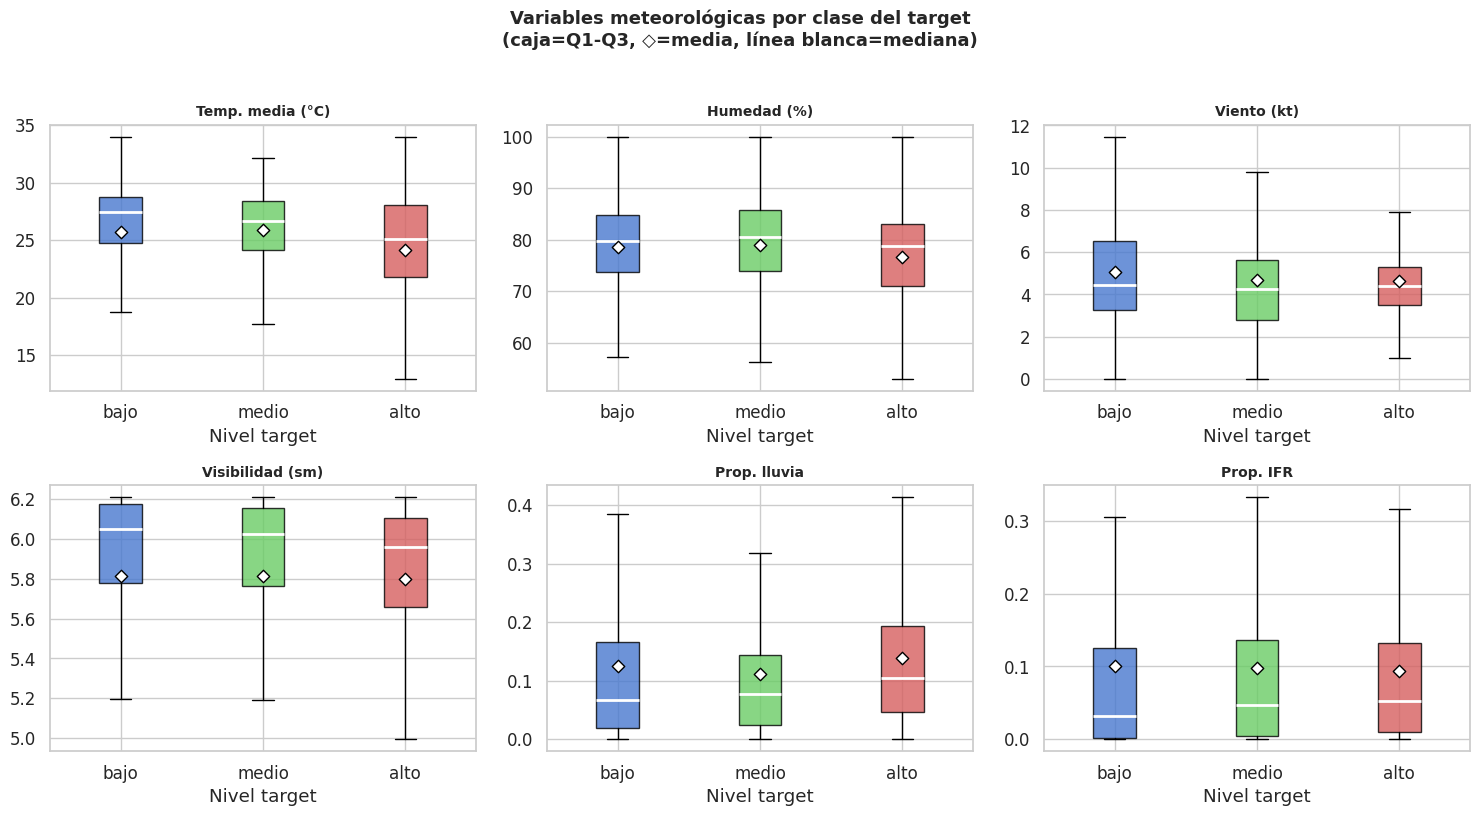

In [24]:
vars_meteo_box = ['temp_media_c', 'humedad_media_pct', 'viento_medio_kt',
                  'visibilidad_media_sm', 'prop_lluvia', 'prop_ifr_aprox']
labels_box     = ['Temp. media (°C)', 'Humedad (%)', 'Viento (kt)',
                  'Visibilidad (sm)', 'Prop. lluvia', 'Prop. IFR']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col, label in zip(axes.flatten(), vars_meteo_box, labels_box):
    data_by_c = [df[df[TARGET_COL] == c][col].dropna().values for c in TARGET_ORDER]
    bp = ax.boxplot(data_by_c, labels=TARGET_ORDER, patch_artist=True,
                    medianprops={'color': 'white', 'linewidth': 2}, showfliers=False)
    for patch, color in zip(bp['boxes'], [PALETTE_TARGET[c] for c in TARGET_ORDER]):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    # Añadir medias como puntos
    for i, (c, vals) in enumerate(zip(TARGET_ORDER, data_by_c)):
        if len(vals) > 0:
            ax.scatter(i+1, np.mean(vals), marker='D', color='white',
                       edgecolors='black', zorder=5, s=40)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('Nivel target')

plt.suptitle('Variables meteorológicas por clase del target\n(caja=Q1-Q3, ◇=media, línea blanca=mediana)',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


###  6.4 Fenómenos meteorológicos adversos 


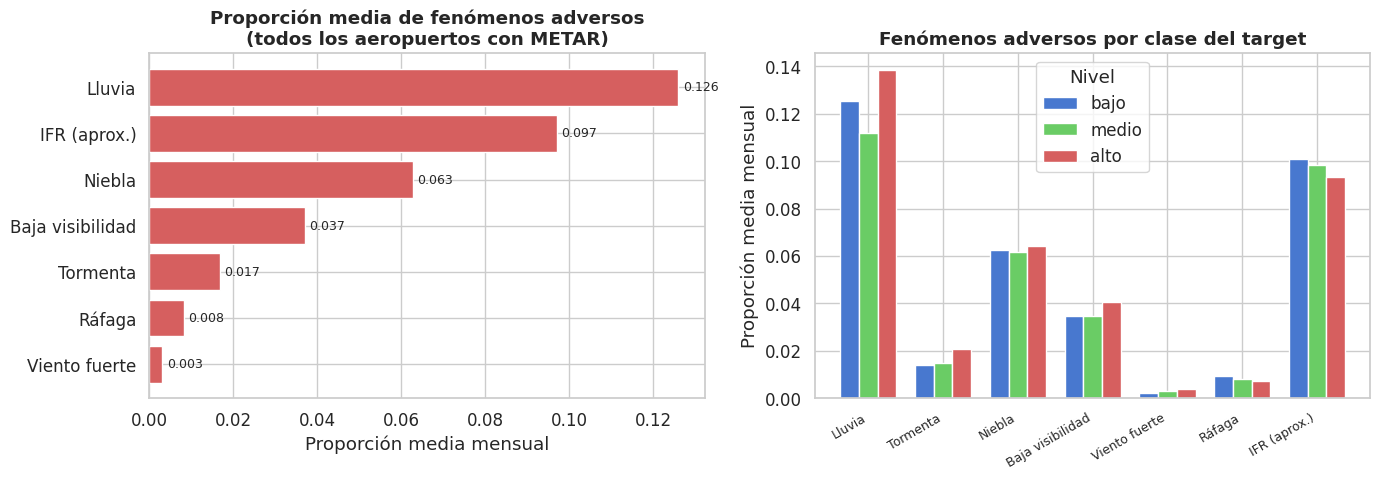

In [25]:
vars_fenomenos = ['prop_lluvia', 'prop_tormenta', 'prop_niebla',
                  'prop_baja_visibilidad', 'prop_viento_fuerte',
                  'prop_rafaga', 'prop_ifr_aprox']
labels_fen = {
    'prop_lluvia':           'Lluvia',
    'prop_tormenta':         'Tormenta',
    'prop_niebla':           'Niebla',
    'prop_baja_visibilidad': 'Baja visibilidad',
    'prop_viento_fuerte':    'Viento fuerte',
    'prop_rafaga':           'Ráfaga',
    'prop_ifr_aprox':        'IFR (aprox.)',
}

# Medias generales
medias_fen = df[vars_fenomenos].mean().rename(labels_fen).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].barh(medias_fen.index, medias_fen.values, color='#D65F5F', edgecolor='white')
for bar, val in zip(bars, medias_fen.values):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
axes[0].set_title('Proporción media de fenómenos adversos\n(todos los aeropuertos con METAR)',
                  fontweight='bold')
axes[0].set_xlabel('Proporción media mensual')

# Por clase del target
fen_by_target = {}
for col in vars_fenomenos:
    fen_by_target[labels_fen[col]] = {
        nivel: df[df[TARGET_COL] == nivel][col].mean()
        for nivel in TARGET_ORDER
    }
df_fen = pd.DataFrame(fen_by_target).T

x = np.arange(len(df_fen))
w = 0.25
for i, nivel in enumerate(TARGET_ORDER):
    axes[1].bar(x + i*w, df_fen[nivel], width=w, label=nivel,
               color=PALETTE_TARGET[nivel], edgecolor='white')
axes[1].set_xticks(x + w)
axes[1].set_xticklabels(df_fen.index, rotation=30, ha='right', fontsize=9)
axes[1].set_title('Fenómenos adversos por clase del target', fontweight='bold')
axes[1].set_ylabel('Proporción media mensual')
axes[1].legend(title='Nivel')

plt.tight_layout()
plt.show()


## 7. EDA geográfico del dataset mensual aeroportuario

In [26]:
df_geo_gold = spark.read.parquet(str(GOLD_MONTHLY_DIR / "monthly_airport_model_dataset.parquet"))

print("Filas:", df_geo_gold.count())
print("Columnas:", len(df_geo_gold.columns))

display(df_geo_gold.limit(5))

Filas: 3254
Columnas: 66


icao_code,fecha_mes,operaciones_llegada,operaciones_salida,TOQUE Y DESPEGUE,operaciones_otras,operaciones_total,pasajeros_salida,carga_salida_kg,n_destinos_total,n_empresas_salida,n_registros_salida,pasajeros_llegada,carga_llegada_kg,n_origenes_total,n_empresas_llegada,n_registros_llegada,pasajeros_total,carga_total_kg,pasajeros_salida_internacional,pasajeros_salida_nacional,pasajeros_llegada_internacional,pasajeros_llegada_nacional,pasajeros_internacional_total,proporcion_pasajeros_internacional,n_metar_mes,temp_media_c,temp_min_c,temp_max_c,temp_std_c,dewpoint_media_c,humedad_media_pct,viento_medio_kt,viento_max_kt,viento_std_kt,rafaga_max_kt,visibilidad_media_sm,visibilidad_min_sm,visibilidad_std_sm,cloud_base_min_ft,altimeter_media_inhg,prop_lluvia,prop_tormenta,prop_niebla,prop_baja_visibilidad,prop_viento_fuerte,prop_rafaga,prop_ifr_aprox,n_metar_esperados_mes,cobertura_metar_ratio,name,type,municipality,region_name,iata_code,latitude_deg,longitude_deg,elevation_ft,scheduled_service,tiene_metar_mes,tiene_od_mes,sin_od_sin_metar_mes,target_operaciones_total_mes_siguiente,target_q33_operaciones,target_q66_operaciones,target_nivel_operacion_mes_siguiente
SKAR,2020-01-01,408.0,409.0,0.0,0.0,817.0,25548.0,119.0,73,5,85,22854.0,0.0,71,5,85,48402.0,119.0,4448.0,21100.0,3880.0,18974.0,8328.0,0.17205900582620554,573,23.653846153846153,15.0,33.00000000000001,4.334010316828683,18.793706293706293,76.9764335664337,1.2,12.0,1.983765392331008,NULL,5.809544658493886,0.62,1.0573798149208826,600.0,30.03521815008726,0.1082024432809773,0.012216404886561954,0.0506108202443281,0.047285464098073555,0.0,0.0,0.04903677758318739,744,0.7701612903225806,El Eden Airport,medium_airport,Armenia,Quindio Department,AXM,4.45278,-75.7664,3990,1,1,1,0,744.0,220.0,564.0,alto
SKAR,2020-02-01,372.0,372.0,0.0,0.0,744.0,22490.0,182.0,66,6,76,22022.0,130.0,71,6,82,44512.0,312.0,3206.0,19284.0,2930.0,19092.0,6136.0,0.1378504672897196,508,23.823762376237624,16.0,34.0,4.35555539518966,18.883168316831682,76.7702772277228,1.2693069306930693,13.0,2.053536562987683,NULL,5.627658730158736,0.19,1.3089271685649784,300.0,30.02348425196852,0.13385826771653545,0.025590551181102362,0.09645669291338582,0.06349206349206349,0.0,0.0,0.06746031746031746,696,0.7298850574712644,El Eden Airport,medium_airport,Armenia,Quindio Department,AXM,4.45278,-75.7664,3990,1,1,1,0,531.0,220.0,564.0,medio
SKAR,2020-03-01,265.0,266.0,0.0,0.0,531.0,13541.0,4170.0,69,7,82,13241.0,3660.0,67,7,87,26782.0,7830.0,1975.0,11566.0,1580.0,11661.0,3555.0,0.13273840639235307,525,23.274193548387096,15.0,30.0,3.243239955496354,17.99794661190965,74.21174537987689,1.5487077534791251,14.0,2.3236857057363314,NULL,5.668011583011595,0.12,1.1737884011598065,800.0,30.029105367793274,0.1180952380952381,0.017142857142857144,0.1180952380952381,0.059845559845559844,0.0,0.0,0.06640625,744,0.7056451612903226,El Eden Airport,medium_airport,Armenia,Quindio Department,AXM,4.45278,-75.7664,3990,1,1,1,0,21.0,220.0,564.0,bajo
SKAR,2020-04-01,11.0,10.0,0.0,0.0,21.0,0.0,17216.0,3,1,3,0.0,16709.0,2,1,2,0.0,33925.0,0.0,0.0,0.0,0.0,0.0,0.0,277,24.25221238938053,18.000000000000004,31.0,3.1542732170856076,19.51769911504425,76.47553097345138,1.736842105263158,9.0,2.3636477132610865,NULL,5.641805054151642,0.19,1.2982877484596589,200.0,30.067268722466956,0.17328519855595667,0.036101083032490974,0.05776173285198556,0.05415162454873646,0.0,0.0,0.08303249097472924,720,0.38472222222222224,El Eden Airport,medium_airport,Armenia,Quindio Department,AXM,4.45278,-75.7664,3990,1,1,1,0,31.0,220.0,564.0,bajo
SKAR,2020-05-01,18.0,13.0,0.0,0.0,31.0,0.0,7891.0,2,2,2,0.0,6061.0,2,2,2,0.0,13952.0,0.0,0.0,0.0,0.0,0.0,0.0,208,25.4126213592233,20.0,32.0,2.790163195214897,20.28640776699029,74.46888349514565,1.3349514563106797,8.0,1.9654185298892481,NULL,5.911730769230784,1.24,0.8861134182296057,800.0,30.071835748792292,0.125,0.004807692307692308,0.0625,0.028846153846153848,0.0,0.0,0.04326923076923077,744,0.27956989247311825,El Eden Airport,medium_airport,Armeni

### 7.1. Generación dataset para gráficas geograficas

In [27]:
df_airports_geo = (
    df_geo_gold
    .select(
        "icao_code",
        "iata_code",
        "name",
        "type",
        "municipality",
        "region_name",
        F.col("latitude_deg").cast("double").alias("latitude_deg"),
        F.col("longitude_deg").cast("double").alias("longitude_deg"),
        F.col("elevation_ft").cast("double").alias("elevation_ft"),
        "scheduled_service",
    )
    .filter(F.col("latitude_deg").isNotNull())
    .filter(F.col("longitude_deg").isNotNull())
    .dropDuplicates(["icao_code"])
)

print("Aeropuertos con coordenadas:", df_airports_geo.count())

display(df_airports_geo)

Aeropuertos con coordenadas: 46


icao_code,iata_code,name,type,municipality,region_name,latitude_deg,longitude_deg,elevation_ft,scheduled_service
SKAR,AXM,El Eden Airport,medium_airport,Armenia,Quindio Department,4.45278,-75.7664,3990.0,1
SKAS,PUU,Tres De Mayo Airport,medium_airport,Puerto Asís,Putumayo Department,0.505228,-76.5008,815.0,1
SKBG,BGA,Palonegro Airport,medium_airport,Bucaramanga,Santander Department,7.1265,-73.1848,3897.0,1
SKBO,BOG,El Dorado Interna...,large_airport,Bogota,Bogotá Capital Di...,4.70159,-74.1469,8361.0,1
SKBQ,BAQ,Ernesto Cortissoz...,large_airport,Barranquilla,Atlántico Department,10.8896,-74.7808,98.0,1
SKBS,BSC,José Celestino Mu...,medium_airport,Bahía Solano,Chocó Department,6.20292,-77.3947,80.0,1
SKBU,BUN,Gerardo Tobar Lóp...,medium_airport,Buenaventura,Valle del Cauca D...,3.81963,-76.9898,48.0,1
SKCC,CUC,Camilo Daza Inter...,medium_airport,Cúcuta,Norte de Santande...,7.92757,-72.5115,1096.0,1
SKCG,CTG,Rafael Nuñez Inte...,large_airport,Cartagena,Bolívar Department,10.4424,-75.513,4.0,1
SKCL,CLO,Alfonso Bonilla A...,large_airport,Cali,Valle del Cauca D...,3.542717,-76.381898,3162.0,1


### 7.2. Preparar columnas geográficas


In [28]:

df_geo_base = (
    df_geo_gold
    .withColumn(
        "latitude_deg_num",
        F.regexp_replace(F.col("latitude_deg").cast("string"), ",", ".").cast("double"),
    )
    .withColumn(
        "longitude_deg_num",
        F.regexp_replace(F.col("longitude_deg").cast("string"), ",", ".").cast("double"),
    )
    .withColumn(
        "elevation_ft_num",
        F.regexp_replace(F.col("elevation_ft").cast("string"), ",", ".").cast("double"),
    )
    .filter(F.col("latitude_deg_num").isNotNull())
    .filter(F.col("longitude_deg_num").isNotNull())
)

print("Filas con coordenadas válidas:", df_geo_base.count())

display(
    df_geo_base
    .select(
        "icao_code",
        "name",
        "municipality",
        "region_name",
        "type",
        "latitude_deg_num",
        "longitude_deg_num",
        "elevation_ft_num",
    )
    .dropDuplicates(["icao_code"])
    .orderBy("icao_code")
)

Filas con coordenadas válidas: 3254


icao_code,name,municipality,region_name,type,latitude_deg_num,longitude_deg_num,elevation_ft_num
SKAR,El Eden Airport,Armenia,Quindio Department,medium_airport,4.45278,-75.7664,3990.0
SKAS,Tres De Mayo Airport,Puerto Asís,Putumayo Department,medium_airport,0.505228,-76.5008,815.0
SKBG,Palonegro Airport,Bucaramanga,Santander Department,medium_airport,7.1265,-73.1848,3897.0
SKBO,El Dorado Interna...,Bogota,Bogotá Capital Di...,large_airport,4.70159,-74.1469,8361.0
SKBQ,Ernesto Cortissoz...,Barranquilla,Atlántico Department,large_airport,10.8896,-74.7808,98.0
SKBS,José Celestino Mu...,Bahía Solano,Chocó Department,medium_airport,6.20292,-77.3947,80.0
SKBU,Gerardo Tobar Lóp...,Buenaventura,Valle del Cauca D...,medium_airport,3.81963,-76.9898,48.0
SKCC,Camilo Daza Inter...,Cúcuta,Norte de Santande...,medium_airport,7.92757,-72.5115,1096.0
SKCG,Rafael Nuñez Inte...,Cartagena,Bolívar Department,large_airport,10.4424,-75.513,4.0
SKCL,Alfonso Bonilla A...,Cali,Valle del Cauca D...,large_airport,3.542717,-76.381898,3162.0


### 7.3. Construir dataset geográfico agregado por aeropuerto


In [29]:
cols_meteo_adverso = [
    "prop_lluvia",
    "prop_tormenta",
    "prop_niebla",
    "prop_baja_visibilidad",
    "prop_viento_fuerte",
    "prop_rafaga",
    "prop_ifr_aprox",
]

cols_meteo_adverso_existentes = [
    col_name
    for col_name in cols_meteo_adverso
    if col_name in df_geo_base.columns
]

if "meteo_adverso_score" not in df_geo_base.columns:

    if len(cols_meteo_adverso_existentes) > 0:

        suma_componentes = None

        for col_name in cols_meteo_adverso_existentes:

            componente = F.coalesce(
                F.col(col_name).cast("double"),
                F.lit(0.0),
            )

            if suma_componentes is None:
                suma_componentes = componente
            else:
                suma_componentes = suma_componentes + componente

        df_geo_base = df_geo_base.withColumn(
            "meteo_adverso_score",
            suma_componentes / F.lit(len(cols_meteo_adverso_existentes)),
        )

        print(
            "[OK] Se creó meteo_adverso_score usando:",
            cols_meteo_adverso_existentes,
        )

    else:
        df_geo_base = df_geo_base.withColumn(
            "meteo_adverso_score",
            F.lit(None).cast("double"),
        )

        print(
            "[WARN] No se encontraron columnas meteorológicas adversas "
            "para crear meteo_adverso_score."
        )


agregaciones_geo = [
    F.count("*").alias("n_meses"),
    F.sum("operaciones_total").alias("operaciones_total_acum"),
    F.avg("operaciones_total").alias("operaciones_total_prom_mes"),
    F.sum("pasajeros_total").alias("pasajeros_total_acum"),
    F.avg("pasajeros_total").alias("pasajeros_total_prom_mes"),
]

if "cobertura_metar_ratio" in df_geo_base.columns:
    agregaciones_geo.append(
        F.avg("cobertura_metar_ratio").alias("cobertura_metar_prom")
    )

if "n_metar_mes" in df_geo_base.columns:
    agregaciones_geo.append(
        F.sum("n_metar_mes").alias("n_metar_total")
    )

if "meteo_adverso_score" in df_geo_base.columns:
    agregaciones_geo.append(
        F.avg("meteo_adverso_score").alias("meteo_adverso_prom")
    )

if "temp_media_c" in df_geo_base.columns:
    agregaciones_geo.append(
        F.avg("temp_media_c").alias("temp_media_prom_c")
    )

if "viento_medio_kt" in df_geo_base.columns:
    agregaciones_geo.append(
        F.avg("viento_medio_kt").alias("viento_medio_prom_kt")
    )

if "visibilidad_media_sm" in df_geo_base.columns:
    agregaciones_geo.append(
        F.avg("visibilidad_media_sm").alias("visibilidad_media_prom_sm")
    )


df_airport_geo_agg = (
    df_geo_base
    .groupBy(
        "icao_code",
        "name",
        "type",
        "municipality",
        "region_name",
        "iata_code",
        "scheduled_service",
        "latitude_deg_num",
        "longitude_deg_num",
        "elevation_ft_num",
    )
    .agg(*agregaciones_geo)
)

display(
    df_airport_geo_agg
    .orderBy(F.desc("operaciones_total_acum"))
)

[OK] Se creó meteo_adverso_score usando: ['prop_lluvia', 'prop_tormenta', 'prop_niebla', 'prop_baja_visibilidad', 'prop_viento_fuerte', 'prop_rafaga', 'prop_ifr_aprox']


icao_code,name,type,municipality,region_name,iata_code,scheduled_service,latitude_deg_num,longitude_deg_num,elevation_ft_num,n_meses,operaciones_total_acum,operaciones_total_prom_mes,pasajeros_total_acum,pasajeros_total_prom_mes,cobertura_metar_prom,n_metar_total,meteo_adverso_prom,temp_media_prom_c,viento_medio_prom_kt,visibilidad_media_prom_sm
SKBO,El Dorado Interna...,large_airport,Bogota,Bogotá Capital Di...,BOG,1,4.70159,-74.1469,8361.0,71,1744239.0,24566.74647887324,1.6547643E8,2330653.943661972,1.0881674470876672,56437,0.05241241373693235,14.077529023199535,5.075974035603335,5.934724246158952
SKRG,Jose Maria Córdov...,large_airport,Medellín,Antioquía Department,MDE,1,6.16454,-75.4231,6955.0,71,493651.0,6952.830985915493,5.7960717E7,816348.1267605633,1.0456834474900323,54231,0.11026976210703529,16.85756731805553,4.153458172151958,5.4155663609996525
SKCL,Alfonso Bonilla A...,large_airport,Cali,Valle del Cauca D...,CLO,1,3.542717,-76.381898,3162.0,71,306941.0,4323.112676056338,3.2231271E7,453961.5633802817,1.0587503702228196,54908,0.051557875849633984,23.668026624603584,4.5787983853328145,5.7374991412208605
SKCG,Rafael Nuñez Inte...,large_airport,Cartagena,Bolívar Department,CTG,1,10.4424,-75.513,4.0,71,253661.0,3572.6901408450703,3.2688287E7,460398.40845070424,0.9774874481719142,50685,0.01763812927299456,28.44026973196675,6.156424919421658,6.128789864068512
SKMD,Enrique Olaya Her...,medium_airport,Medellín,Antioquía Department,EOH,1,6.219686,-75.590597,4949.0,71,181879.0,2561.676056338028,6606734.0,93052.59154929577,0.4756854739552908,23974,0.05074995682062971,23.464979773967485,5.804461168560966,6.033082996434448
SKBQ,Ernesto Cortissoz...,large_airport,Barranquilla,Atlántico Department,BAQ,1,10.8896,-74.7808,98.0,71,165595.0,2332.323943661972,1.5059954E7,212112.02816901408,1.0343663560276504,53646,0.04312038361398876,27.909855418319417,6.628398072670833,5.906370372730164
SKBG,Palonegro Airport,medium_airport,Bucaramanga,Santander Department,BGA,1,7.1265,-73.1848,3897.0,71,141342.0,1990.7323943661972,9737843.0,137152.71830985916,0.7977210003314907,41372,0.05021458285760817,22.537703016476225,4.391734867058646,5.810880224163559
SKQU,Mariquita Airport,medium_airport,Mariquita,Tolima Department,MQU,0,5.21256,-74.8836,1531.0,71,134185.0,1889.9295774647887,611.0,8.605633802816902,0.3201359450899381,7953,0.031224941108885806,27.010147698682395,3.891460806038103,5.599536672648374
SKSM,Simón Bolívar Int...,medium_airport,Santa Marta,Magdalena Department,SMR,1,11.1196,-74.2306,22.0,71,121907.0,1717.0,1.6818305E7,236877.53521126762,0.6886818951653312,35700,0.011484317240374277,29.391287587027044,6.412679419740538,6.174242611793648
SKPE,Matecaña Internat...,medium_airport,Pereira,Risaralda Department,PEI,1,4.81267,-75.7395,4416.0,71,108262.0,1524.8169014084508,1.1681624E7,164529.91549295775,0.8462473472027318,43879,0.05950923379533491,22.248524333744143,4.503743260977702,5.759533697413473


### 7.4. Función auxiliar para mapas Plotly

In [30]:
def mostrar_mapa_plotly(
    df_pd,
    lat_col,
    lon_col,
    title,
    color_col=None,
    size_col=None,
    hover_name_col="name",
    hover_data=None,
    zoom=4.7,
    height=720,
    center_lat=4.5709,
    center_lon=-74.2973,
    map_style="open-street-map",
    marker_size=10,
    size_max=18,
    opacity=0.80,
    color_discrete_map=None,
    color_continuous_scale="Viridis",
    ordenar_por_size=True,
    ascending_size=False,
):
    """
    Crea mapa interactivo con Plotly.

    Esta versión mantiene compatibilidad con parámetros usados antes:
    - center_lat
    - center_lon
    - map_style
    - marker_size
    - size_max
    - opacity
    - color_discrete_map
    - color_continuous_scale

    También permite ordenar por tamaño para mejorar visibilidad.
    """

    df_plot = df_pd.copy()

    # Asegurar coordenadas numéricas
    df_plot[lat_col] = pd.to_numeric(
        df_plot[lat_col],
        errors="coerce",
    )

    df_plot[lon_col] = pd.to_numeric(
        df_plot[lon_col],
        errors="coerce",
    )

    df_plot = df_plot.dropna(
        subset=[
            lat_col,
            lon_col,
        ]
    )

    # Preparar tamaño si existe size_col
    if size_col is not None and size_col in df_plot.columns:
        df_plot[size_col] = pd.to_numeric(
            df_plot[size_col],
            errors="coerce",
        ).fillna(0)

        if ordenar_por_size:
            df_plot = df_plot.sort_values(
                by=size_col,
                ascending=ascending_size,
            )

    center = {
        "lat": center_lat,
        "lon": center_lon,
    }

    common_args = dict(
        data_frame=df_plot,
        lat=lat_col,
        lon=lon_col,
        color=color_col,
        size=size_col,
        hover_name=hover_name_col,
        hover_data=hover_data,
        zoom=zoom,
        center=center,
        height=height,
        title=title,
        size_max=size_max,
        color_discrete_map=color_discrete_map,
        color_continuous_scale=color_continuous_scale,
    )

    # Usar px.scatter_map si está disponible
    if hasattr(px, "scatter_map"):

        fig = px.scatter_map(**common_args)

        fig.update_layout(
            map_style=map_style,
            template="plotly_white",
            paper_bgcolor="white",
            plot_bgcolor="white",
            margin={
                "r": 10,
                "t": 60,
                "l": 10,
                "b": 10,
            },
            title={
                "x": 0.5,
                "xanchor": "center",
                "font": {
                    "size": 20,
                },
            },
            legend=dict(
                title=color_col if color_col else "",
                bgcolor="rgba(255,255,255,0.90)",
                bordercolor="rgba(0,0,0,0.25)",
                borderwidth=1,
            ),
        )

    # Fallback: px.scatter_mapbox
    else:

        fig = px.scatter_mapbox(**common_args)

        fig.update_layout(
            mapbox_style=map_style,
            template="plotly_white",
            paper_bgcolor="white",
            plot_bgcolor="white",
            margin={
                "r": 10,
                "t": 60,
                "l": 10,
                "b": 10,
            },
            title={
                "x": 0.5,
                "xanchor": "center",
                "font": {
                    "size": 20,
                },
            },
            legend=dict(
                title=color_col if color_col else "",
                bgcolor="rgba(255,255,255,0.90)",
                bordercolor="rgba(0,0,0,0.25)",
                borderwidth=1,
            ),
        )

    # Mejorar visibilidad de puntos
    if size_col is None:
        fig.update_traces(
            marker=dict(
                size=marker_size,
                opacity=opacity,
            )
        )
    else:
        fig.update_traces(
            marker=dict(
                opacity=opacity,
            )
        )

    fig.show()

    return fig

### 7.5. Mapa 1: distribución geográfica de aeropuertos

In [31]:

airport_geo_pd = df_airport_geo_agg.toPandas()

color_map_airport_type = {
    "large_airport": "#E63946",    # rojo fuerte
    "medium_airport": "#F77F00",   # naranja fuerte
    "small_airport": "#0077B6",    # azul fuerte
}

fig_geo = mostrar_mapa_plotly(
    df_pd=airport_geo_pd,
    lat_col="latitude_deg_num",
    lon_col="longitude_deg_num",
    title="Distribución geográfica de aeropuertos en el dataset",
    color_col="type",
    size_col=None,
    hover_name_col="name",
    hover_data=[
        "icao_code",
        "municipality",
        "region_name",
        "operaciones_total_acum",
        "pasajeros_total_acum",
    ],
    zoom=5.0,
    height=760,
    center_lat=4.5709,
    center_lon=-74.2973,
    map_style="carto-positron",
    marker_size=15,
    opacity=0.98,
    color_discrete_map=color_map_airport_type,
)

### 7.6. Mapa 2: concentración de operaciones por aeropuerto

In [32]:
airport_geo_pd = df_airport_geo_agg.toPandas()

airport_geo_pd["operaciones_total_acum_plot"] = np.log1p(
    airport_geo_pd["operaciones_total_acum"]
)

airport_geo_pd["operaciones_total_acum_color"] = np.log1p(
    airport_geo_pd["operaciones_total_acum"]
)

fig_operaciones = mostrar_mapa_plotly(
    df_pd=airport_geo_pd,
    lat_col="latitude_deg_num",
    lon_col="longitude_deg_num",
    title="Concentración geográfica de operaciones aeroportuarias",
    color_col="operaciones_total_acum_color",
    size_col="operaciones_total_acum_plot",
    hover_name_col="name",
    hover_data=[
        "icao_code",
        "municipality",
        "region_name",
        "type",
        "operaciones_total_acum",
        "operaciones_total_prom_mes",
        "pasajeros_total_acum",
        "n_meses",
    ],
    zoom=4.6,
    height=750,
    color_continuous_scale="Turbo",
    map_style="carto-positron",
)

### 7.7. Mapa 3: concentración de pasajeros por aeropuerto

In [33]:

# Tamaño de burbuja en escala logarítmica
airport_geo_pd["pasajeros_total_acum_plot"] = np.log1p(
    airport_geo_pd["pasajeros_total_acum"]
)

# Color también en escala logarítmica para mejorar contraste visual
airport_geo_pd["pasajeros_total_acum_color"] = np.log1p(
    airport_geo_pd["pasajeros_total_acum"]
)


fig_pasajeros = mostrar_mapa_plotly(
    df_pd=airport_geo_pd,
    lat_col="latitude_deg_num",
    lon_col="longitude_deg_num",
    title="Concentración geográfica de pasajeros por aeropuerto",
    color_col="pasajeros_total_acum",
    size_col="pasajeros_total_acum_plot",
    hover_name_col="name",
    hover_data=[
        "icao_code",
        "municipality",
        "region_name",
        "type",
        "pasajeros_total_acum",
        "pasajeros_total_prom_mes",
        "operaciones_total_acum",
        "operaciones_total_prom_mes",
        "n_meses",
    ],
    zoom=4.6,
    height=750,
    map_style="carto-positron",
    size_max=12,
    opacity=0.95,
    color_continuous_scale="Turbo",
)

### 7.8. Mapa 4: clase target predominante por aeropuerto

In [34]:
from pyspark.sql import Window
df_target_airport = (
    df_geo_base
    .groupBy(
        "icao_code",
        "target_nivel_operacion_mes_siguiente",
    )
    .agg(
        F.count("*").alias("n_meses_clase")
    )
)

window_target_airport = Window.partitionBy("icao_code").orderBy(
    F.desc("n_meses_clase")
)

df_target_airport_top = (
    df_target_airport
    .withColumn(
        "rank_clase",
        F.row_number().over(window_target_airport),
    )
    .filter(F.col("rank_clase") == 1)
    .drop("rank_clase")
)

df_airport_target_geo = (
    df_airport_geo_agg
    .join(
        df_target_airport_top,
        on="icao_code",
        how="left",
    )
)

airport_target_geo_pd = df_airport_target_geo.toPandas()

airport_target_geo_pd["operaciones_total_acum_plot"] = np.log1p(
    airport_target_geo_pd["operaciones_total_acum"]
)

fig_target = mostrar_mapa_plotly(
    df_pd=airport_target_geo_pd,
    lat_col="latitude_deg_num",
    lon_col="longitude_deg_num",
    title="Nivel de operación predominante por aeropuerto",
    color_col="target_nivel_operacion_mes_siguiente",
    size_col="operaciones_total_acum_plot",
    hover_name_col="name",
    hover_data=[
        "icao_code",
        "municipality",
        "region_name",
        "type",
        "target_nivel_operacion_mes_siguiente",
        "n_meses_clase",
        "operaciones_total_acum",
        "pasajeros_total_acum",
    ],
    zoom=4.6,
    height=750,
    map_style="carto-positron",
    size_max=12,
    opacity=0.95,
)

### 7.9. Mapa 5: cobertura METAR promedio por aeropuerto

In [35]:
airport_metar_geo_pd = (
    df_airport_geo_agg
    .filter(F.col("cobertura_metar_prom").isNotNull())
    .toPandas()
)

airport_metar_geo_pd["n_metar_total_plot"] = np.log1p(
    airport_metar_geo_pd["n_metar_total"]
)

fig_metar = mostrar_mapa_plotly(
    df_pd=airport_metar_geo_pd,
    lat_col="latitude_deg_num",
    lon_col="longitude_deg_num",
    title="Cobertura METAR promedio por aeropuerto",
    color_col="cobertura_metar_prom",
    size_col="n_metar_total_plot",
    hover_name_col="name",
    hover_data=[
        "icao_code",
        "municipality",
        "region_name",
        "type",
        "cobertura_metar_prom",
        "n_metar_total",
        "operaciones_total_acum",
        "pasajeros_total_acum",
    ],
    zoom=4.6,
    height=750,
    map_style="carto-positron",
    size_max=12,
    opacity=0.95,
    color_continuous_scale="Turbo",
)

### 7.10. Mapa 6: temperatura media promedio por aeropuerto

In [36]:

airport_temp_geo_pd = (
    df_airport_geo_agg
    .filter(F.col("temp_media_prom_c").isNotNull())
    .toPandas()
)

airport_temp_geo_pd["operaciones_total_acum_plot"] = np.log1p(
    airport_temp_geo_pd["operaciones_total_acum"]
)

fig_temp = mostrar_mapa_plotly(
    df_pd=airport_temp_geo_pd,
    lat_col="latitude_deg_num",
    lon_col="longitude_deg_num",
    title="Temperatura media promedio por aeropuerto",
    color_col="temp_media_prom_c",
    size_col="operaciones_total_acum_plot",
    hover_name_col="name",
    hover_data=[
        "icao_code",
        "municipality",
        "region_name",
        "type",
        "temp_media_prom_c",
        "operaciones_total_acum",
        "pasajeros_total_acum",
    ],
    zoom=4.6,
    height=750,
    map_style="carto-positron",
    size_max=12,
    opacity=0.95,
    color_continuous_scale="Turbo",
)

### 7.11. Mapa 7: viento medio promedio por aeropuerto

In [37]:

airport_wind_geo_pd = (
    df_airport_geo_agg
    .filter(F.col("viento_medio_prom_kt").isNotNull())
    .toPandas()
)

airport_wind_geo_pd["operaciones_total_acum_plot"] = np.log1p(
    airport_wind_geo_pd["operaciones_total_acum"]
)

fig_viento = mostrar_mapa_plotly(
    df_pd=airport_wind_geo_pd,
    lat_col="latitude_deg_num",
    lon_col="longitude_deg_num",
    title="Viento medio promedio por aeropuerto",
    color_col="viento_medio_prom_kt",
    size_col="operaciones_total_acum_plot",
    hover_name_col="name",
    hover_data=[
        "icao_code",
        "municipality",
        "region_name",
        "type",
        "viento_medio_prom_kt",
        "operaciones_total_acum",
        "pasajeros_total_acum",
    ],
    zoom=4.6,
    height=750,
    map_style="carto-positron",
    size_max=12,
    opacity=0.95,
    color_continuous_scale="Turbo",
)

### 7.12. Mapa 8: visibilidad media promedio por aeropuerto

In [38]:

airport_vis_geo_pd = (
    df_airport_geo_agg
    .filter(F.col("visibilidad_media_prom_sm").isNotNull())
    .toPandas()
)

airport_vis_geo_pd["operaciones_total_acum_plot"] = np.log1p(
    airport_vis_geo_pd["operaciones_total_acum"]
)

fig_visibilidad = mostrar_mapa_plotly(
    df_pd=airport_vis_geo_pd,
    lat_col="latitude_deg_num",
    lon_col="longitude_deg_num",
    title="Visibilidad media promedio por aeropuerto",
    color_col="visibilidad_media_prom_sm",
    size_col="operaciones_total_acum_plot",
    hover_name_col="name",
    hover_data=[
        "icao_code",
        "municipality",
        "region_name",
        "type",
        "visibilidad_media_prom_sm",
        "operaciones_total_acum",
        "pasajeros_total_acum",
    ],
    zoom=4.6,
    height=750,
    map_style="carto-positron",
    size_max=12,
    opacity=0.95,
    color_continuous_scale="Turbo",
)

### 7.13. Resumen regional de operaciones


In [39]:

df_region_geo_summary = (
    df_geo_base
    .groupBy("region_name")
    .agg(
        F.countDistinct("icao_code").alias("n_aeropuertos"),
        F.sum("operaciones_total").alias("operaciones_total_acum"),
        F.avg("operaciones_total").alias("operaciones_prom_mes"),
        F.sum("pasajeros_total").alias("pasajeros_total_acum"),
        F.avg("pasajeros_total").alias("pasajeros_prom_mes"),
        F.avg("cobertura_metar_ratio").alias("cobertura_metar_prom"),
    )
    .orderBy(F.desc("operaciones_total_acum"))
)

display(df_region_geo_summary)

region_name,n_aeropuertos,operaciones_total_acum,operaciones_prom_mes,pasajeros_total_acum,pasajeros_prom_mes,cobertura_metar_prom
Bogotá Capital Di...,2,1796910.0,12654.295774647888,1.65489019E8,1165415.6267605633,0.8485623928337398
Antioquía Department,3,714029.0,3352.2488262910797,6.5700777E7,308454.3521126761,0.7189962742798195
Valle del Cauca D...,3,312306.0,1508.7246376811595,3.2277548E7,155930.18357487922,0.6681323360360086
Bolívar Department,1,253661.0,3572.6901408450703,3.2688287E7,460398.40845070424,0.9774874481719142
Santander Department,2,190276.0,1339.9718309859154,1.036072E7,72962.81690140846,0.6999957670362764
Tolima Department,2,173802.0,1223.9577464788733,863463.0,6080.725352112676,0.5336696448059103
Atlántico Department,1,165595.0,2332.323943661972,1.5059954E7,212112.02816901408,1.0343663560276504
Magdalena Department,1,121907.0,1717.0,1.6818305E7,236877.53521126762,0.6886818951653312
"San Andrés, Provi...",2,117724.0,829.0422535211268,1.3071976E7,92056.1690140845,0.7836136045805345
Risaralda Department,1,108262.0,1524.8169014084508,1.1681624E7,164529.91549295775,0.8462473472027318


### 7.14. Gráfico regional de operaciones

In [40]:

region_geo_pd = df_region_geo_summary.toPandas()

fig_region = px.bar(
    region_geo_pd.sort_values("operaciones_total_acum"),
    x="operaciones_total_acum",
    y="region_name",
    orientation="h",
    title="Operaciones acumuladas por región",
    hover_data={
        "n_aeropuertos": True,
        "operaciones_total_acum": ":,.0f",
        "operaciones_prom_mes": ":,.1f",
        "pasajeros_total_acum": ":,.0f",
        "pasajeros_prom_mes": ":,.1f",
        "cobertura_metar_prom": ":.2f",
    },
)

fig_region.update_layout(
    height=750,
    template="plotly_white",
    margin={
        "r": 20,
        "t": 60,
        "l": 20,
        "b": 40,
    },
    title={
        "x": 0.5,
        "xanchor": "center",
    },
    xaxis_title="Operaciones acumuladas",
    yaxis_title="Región",
)

fig_region.show()

### 7.15. Guardar mapas como HTML interactivo

In [41]:

GEO_EDA_DIR = GOLD_MONTHLY_DIR / "eda_geo"

GEO_EDA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

fig_geo.write_html(
    str(GEO_EDA_DIR / "mapa_01_aeropuertos_tipo.html")
)

fig_operaciones.write_html(
    str(GEO_EDA_DIR / "mapa_02_operaciones_aeropuerto.html")
)

fig_pasajeros.write_html(
    str(GEO_EDA_DIR / "mapa_03_pasajeros_aeropuerto.html")
)

fig_target.write_html(
    str(GEO_EDA_DIR / "mapa_04_target_predominante.html")
)

fig_metar.write_html(
    str(GEO_EDA_DIR / "mapa_05_cobertura_metar.html")
)

fig_temp.write_html(
    str(GEO_EDA_DIR / "mapa_06_temperatura_media.html")
)

fig_viento.write_html(
    str(GEO_EDA_DIR / "mapa_07_viento_medio.html")
)

fig_visibilidad.write_html(
    str(GEO_EDA_DIR / "mapa_08_visibilidad_media.html")
)

fig_region.write_html(
    str(GEO_EDA_DIR / "grafico_09_operaciones_region.html")
)

print("[OK] Mapas y gráficos geográficos guardados en:")
print(GEO_EDA_DIR)

[OK] Mapas y gráficos geográficos guardados en:
data_proyecto_aeropuertos/gold/monthly_airport_dataset/eda_geo


## 8. Correlaciones con el target

In [42]:
target_col = "target_operaciones_total_mes_siguiente"

columnas_excluir = [
    "target_q33_operaciones",
    "target_q66_operaciones",
    "target_nivel_operacion_mes_siguiente",
]

cols_numericas = (
    df
    .select_dtypes(include="number")
    .columns
    .drop(columnas_excluir, errors="ignore")
    .to_list()
)

if target_col not in cols_numericas:
    raise ValueError(f"No existe la columna target numérica: {target_col}")

corr_con_target = (
    df[cols_numericas]
    .corr(method="spearman")[target_col]
    .drop(target_col, errors="ignore")
    .dropna()
    .sort_values()
)

top_n_pos = 15
top_n_neg = 15

corr_negativas = corr_con_target.head(top_n_neg)

corr_positivas = corr_con_target.tail(top_n_pos).sort_values(ascending=False)

cols_corr_negativas = corr_negativas.index.to_list()

cols_corr_positivas = corr_positivas.index.to_list()

cols_clave_corr = (
    cols_corr_positivas
    + [
        col
        for col in cols_corr_negativas
        if col not in cols_corr_positivas
    ]
)

cols_heatmap = cols_clave_corr + [target_col]

top_n = top_n_pos + top_n_neg + 1


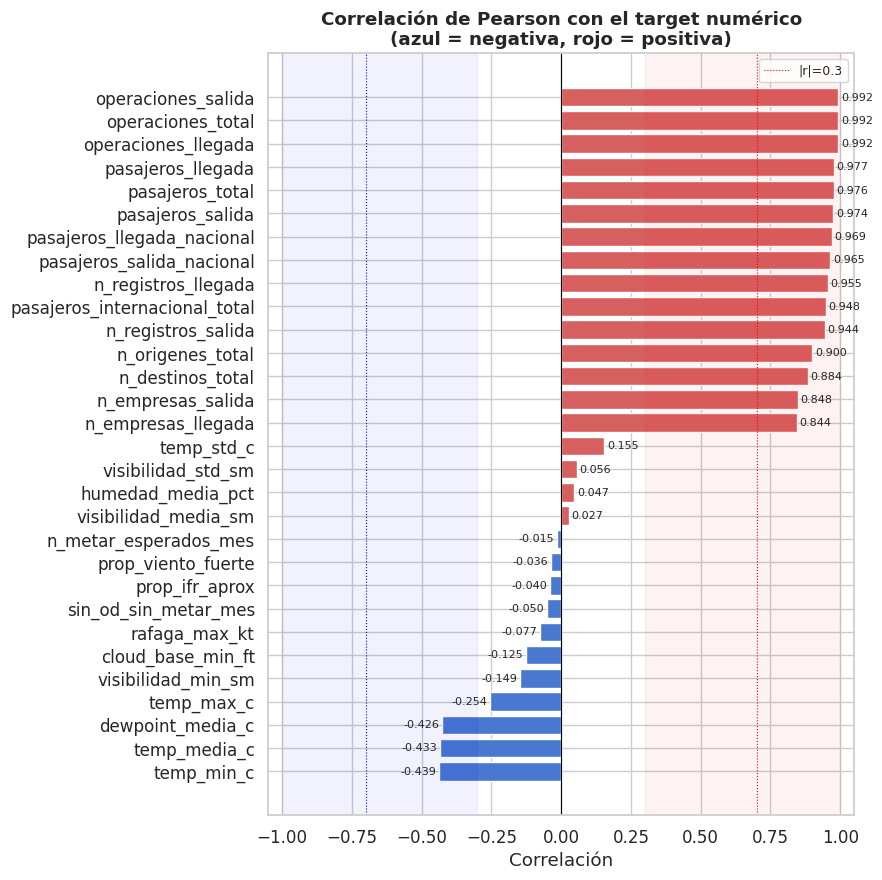

In [43]:
# --- 8.1.1. Correlación Pearson de variables numéricas con el target numérico ---
corr_target = (
    df[cols_heatmap]
    .corr(method='pearson')['target_operaciones_total_mes_siguiente']
    .drop('target_operaciones_total_mes_siguiente')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 9))
colors = ['#D65F5F' if v > 0 else '#4878CF' for v in corr_target.values]
bars   = ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')

# Zonas de referencia
ax.axvspan(-1, -0.3, alpha=0.05, color='blue')
ax.axvspan(0.3,  1,  alpha=0.05, color='red')
ax.axvline(0,    color='black', linewidth=0.8)
ax.axvline(0.7,  color='red',   linestyle=':', linewidth=0.8, label='|r|=0.3')
ax.axvline(-0.7, color='blue',  linestyle=':', linewidth=0.8)

for bar, val in zip(bars, corr_target.values):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8)
ax.set_title('Correlación de Pearson con el target numérico\n(azul = negativa, rojo = positiva)',
             fontweight='bold')
ax.set_xlabel('Correlación')
ax.legend(fontsize=9)
ax.set_xlim(-1.05, 1.05)
plt.tight_layout()
plt.show()


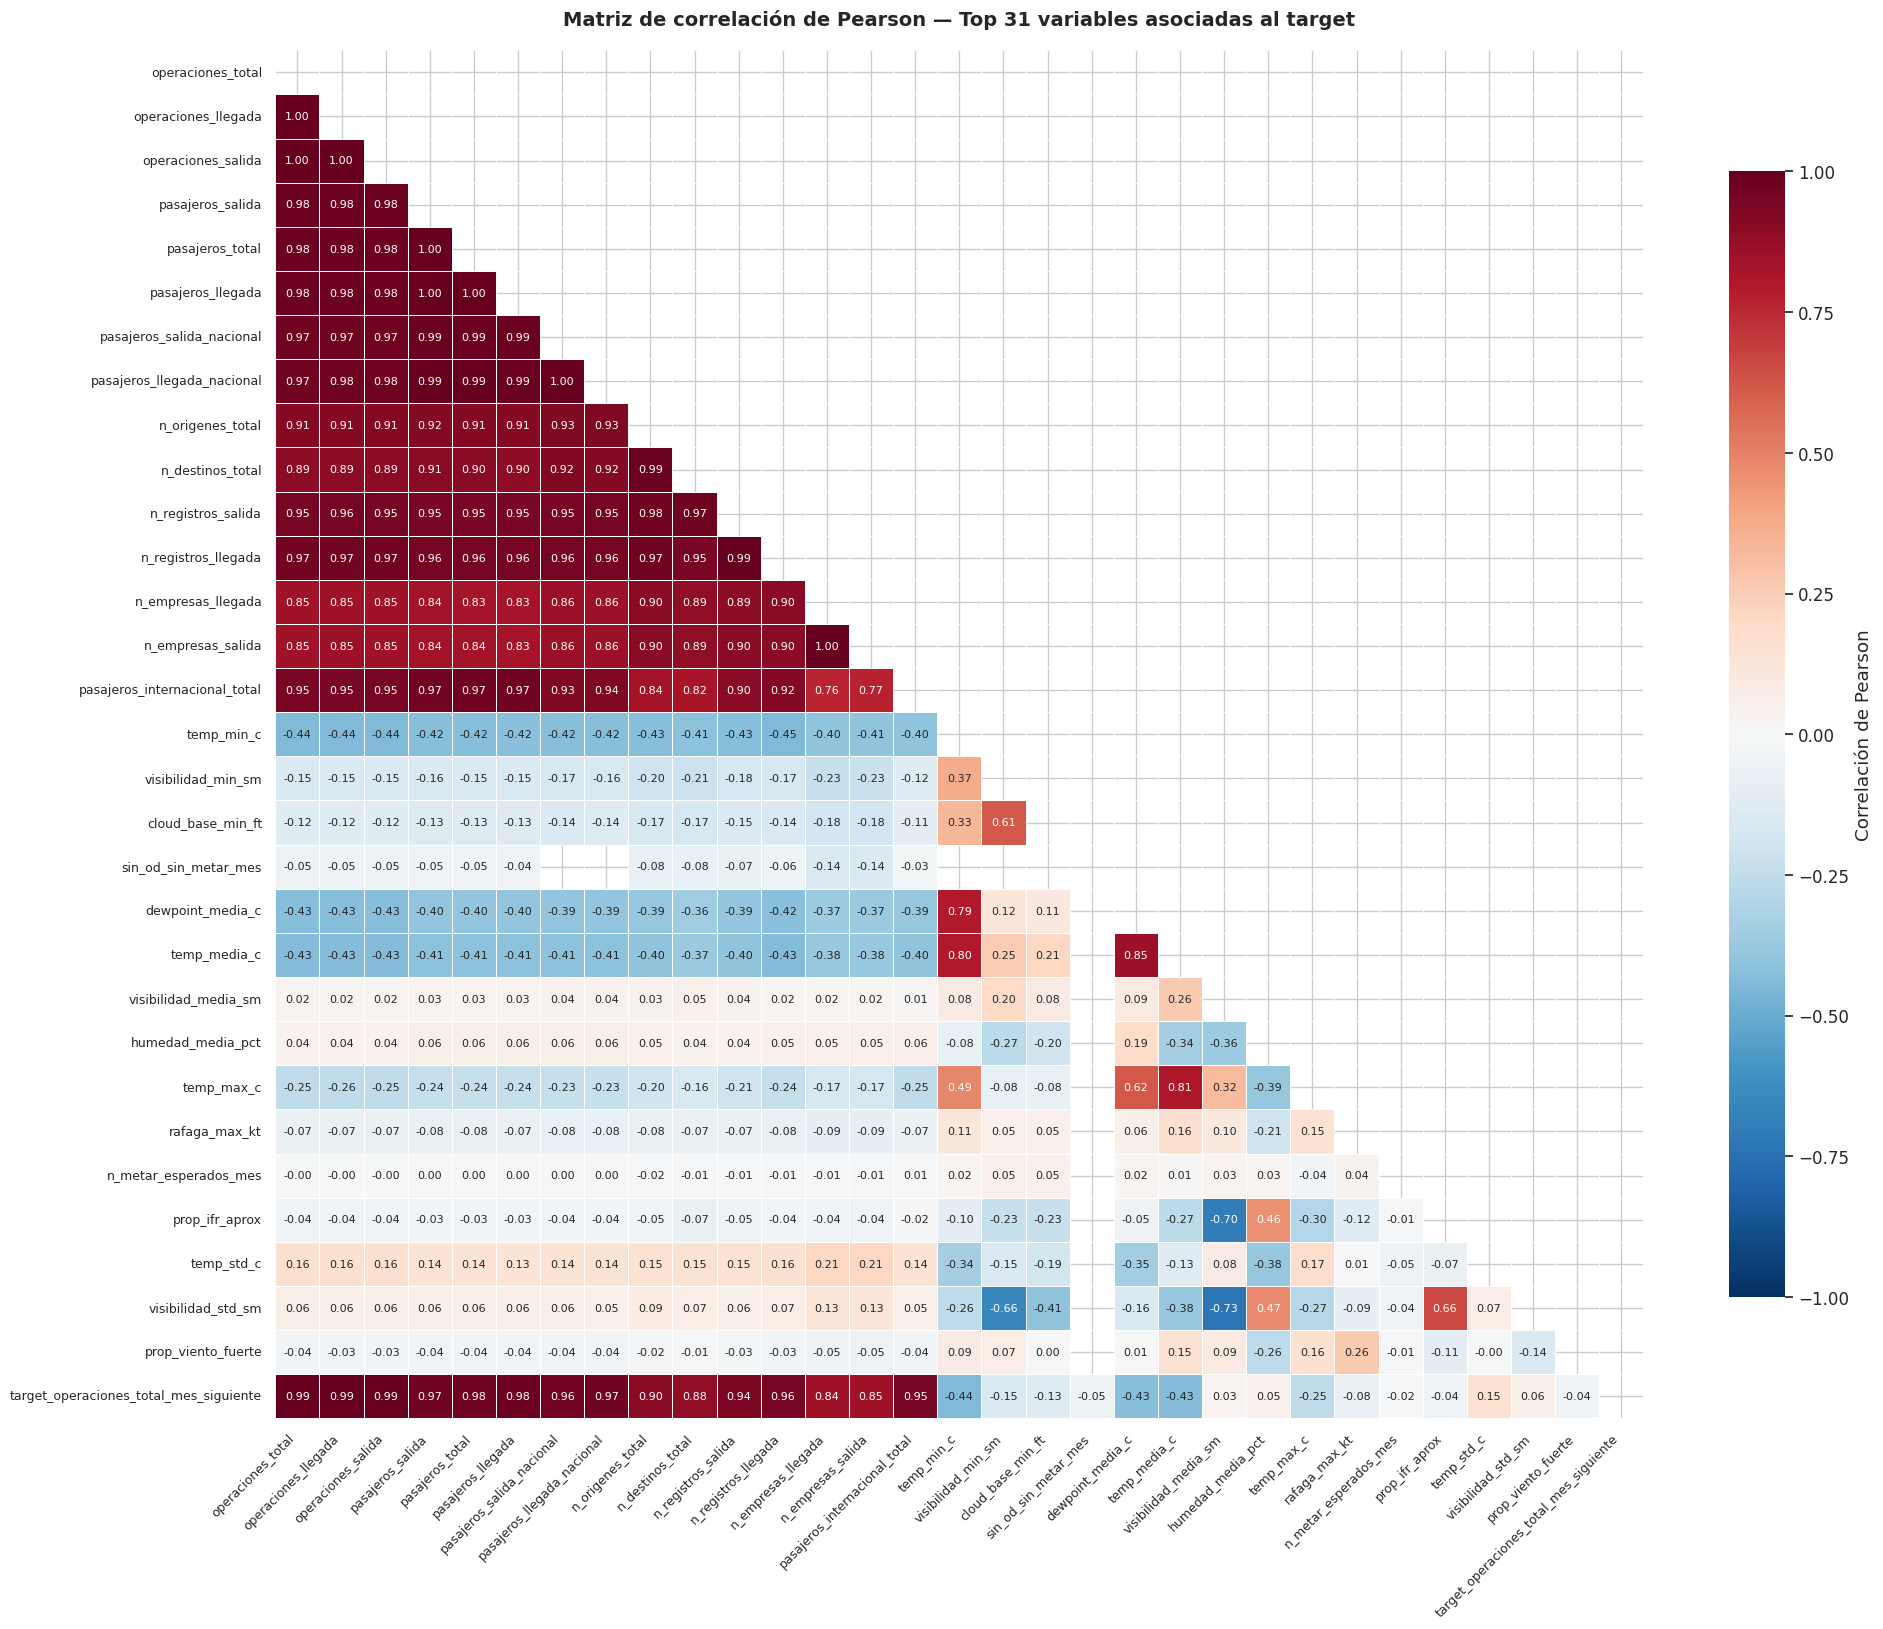

In [44]:
# --- 8.1.2 Heatmap de correlación pearson entre variables clave ---
corr_matrix_pearson = df[cols_heatmap].corr(method="pearson")

figsize_base = max(10, len(cols_heatmap) * 0.65)

fig, ax = plt.subplots(figsize=(figsize_base, figsize_base * 0.85))

mask = np.triu(
    np.ones_like(corr_matrix_pearson, dtype=bool)
)

sns.heatmap(
    corr_matrix_pearson, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", 
    center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5, 
    linecolor="white", square=True,
    cbar_kws={
        "shrink": 0.75,
        "label": "Correlación de Pearson",
    },
    annot_kws={
        "size": 8,
    },
)

ax.set_title(
    f"Matriz de correlación de Pearson — Top {top_n} variables asociadas al target",
    fontweight="bold",
    fontsize=14, pad=18,
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45, ha="right", fontsize=9,
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0, fontsize=9,
)

plt.tight_layout()
plt.show()

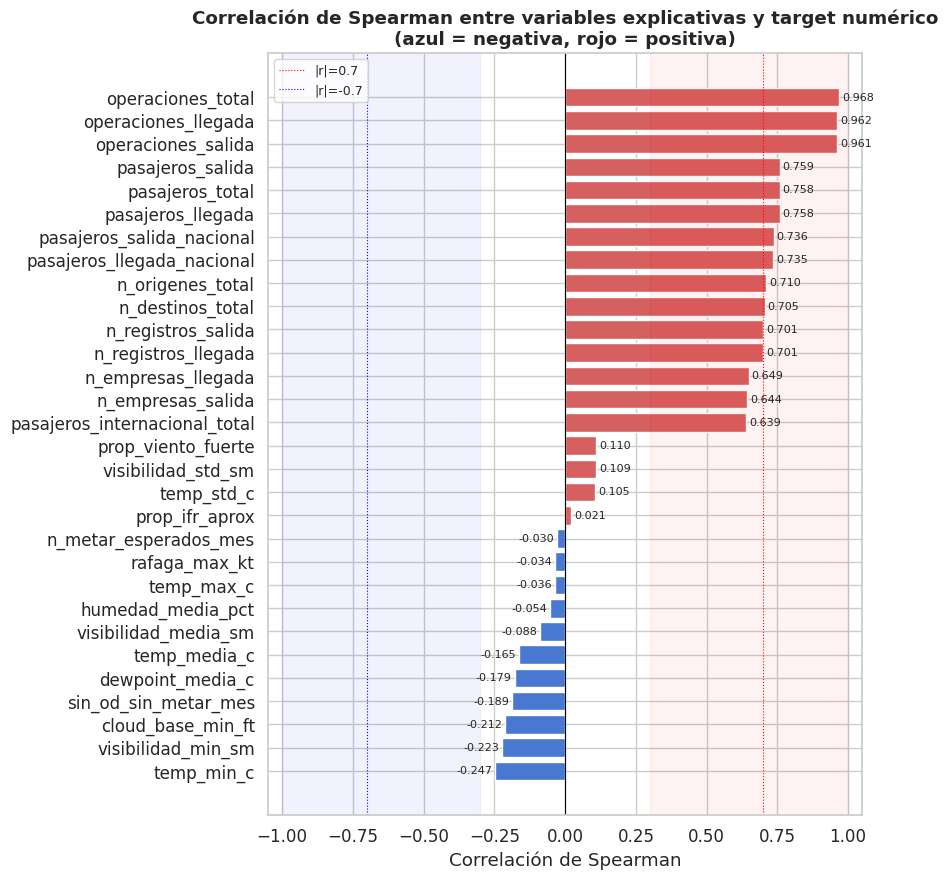

In [45]:
# --- 8.2.1 Correlación Spearman de variables explicativas numéricas con el target numérico ---
corr_target = (
    df[cols_heatmap]
    .corr(method='spearman')['target_operaciones_total_mes_siguiente']
    .drop('target_operaciones_total_mes_siguiente')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 9))

colors = [
    "#D65F5F" if v > 0 else "#4878CF"
    for v in corr_target.values
]

bars = ax.barh(
    corr_target.index,
    corr_target.values,
    color=colors,
    edgecolor="white"
)

ax.axvspan(-1, -0.3, alpha=0.05, color="blue")
ax.axvspan(0.3, 1, alpha=0.05, color="red")
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(0.7, color="red", linestyle=":", linewidth=0.8, label="|r|=0.7")
ax.axvline(-0.7, color="blue", linestyle=":", linewidth=0.8, label="|r|=-0.7")

for bar, val in zip(bars, corr_target.values):
    ax.text(
        val + (0.01 if val >= 0 else -0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=8,
    )

ax.set_title(
    "Correlación de Spearman entre variables explicativas y target numérico\n"
    "(azul = negativa, rojo = positiva)",
    fontweight="bold",
)

ax.set_xlabel("Correlación de Spearman")
ax.legend(fontsize=9)
ax.set_xlim(-1.05, 1.05)

plt.tight_layout()
plt.show()

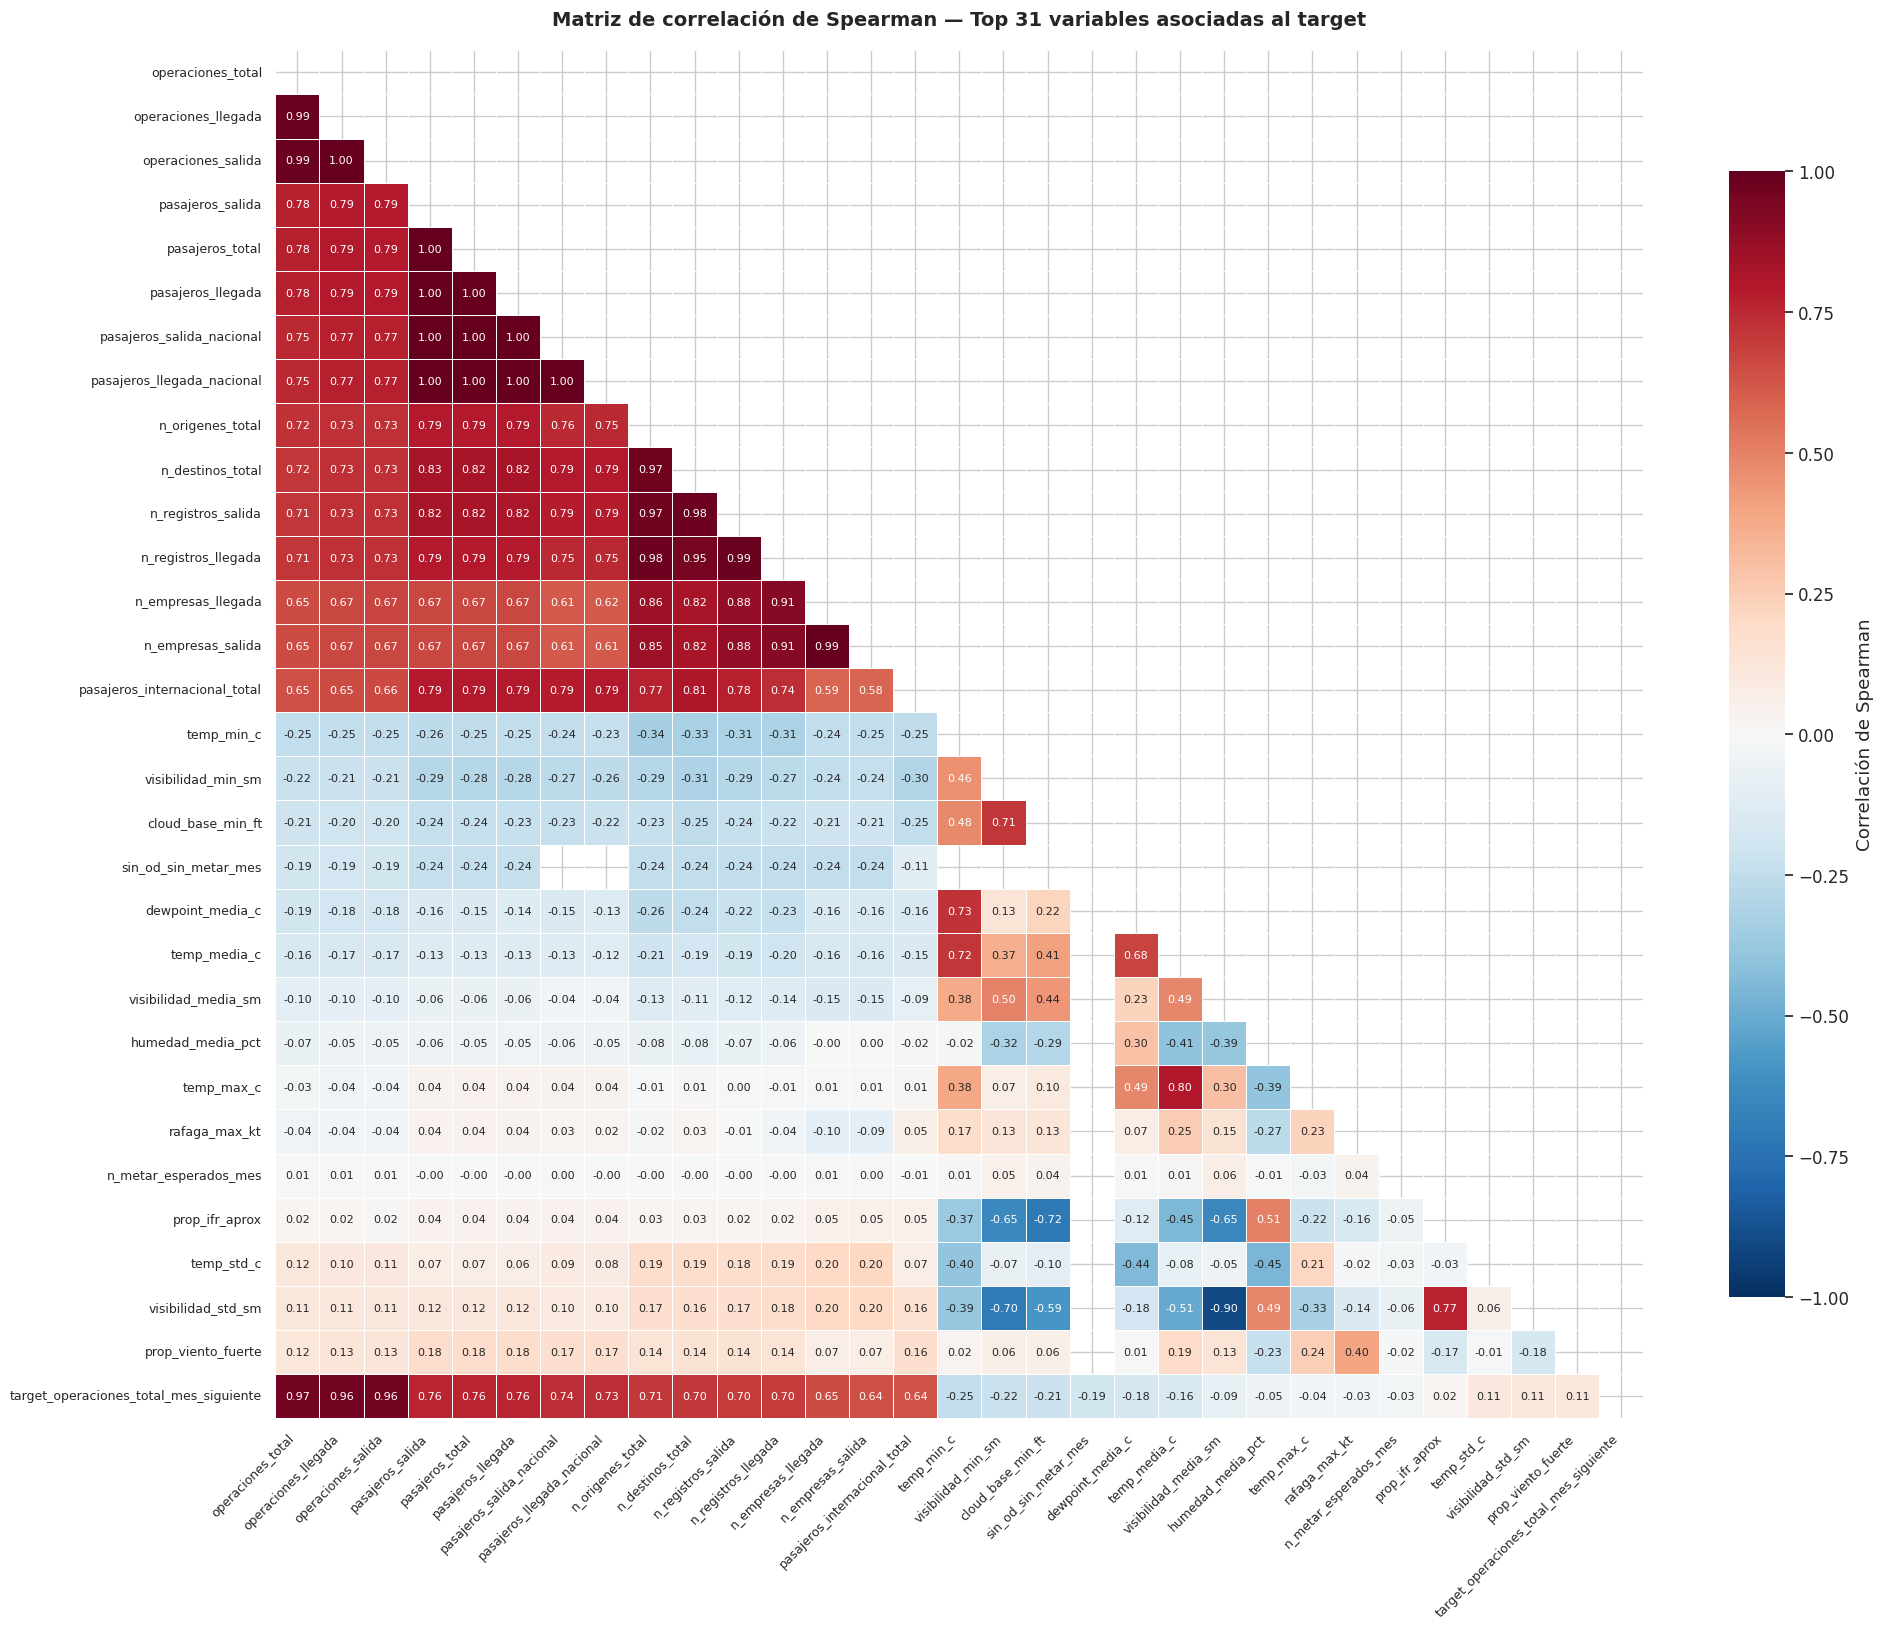

In [46]:
# --- 8.2.2 Heatmap de correlación spearman entre variables clave ---
corr_matrix_spearman = df[cols_heatmap].corr(method="spearman")

figsize_base = max(10, len(cols_heatmap) * 0.65)

fig, ax = plt.subplots(figsize=(figsize_base, figsize_base * 0.85))

mask = np.triu(
    np.ones_like(corr_matrix_spearman, dtype=bool)
)

sns.heatmap(
    corr_matrix_spearman, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, ax=ax,
    linewidths=0.5, linecolor="white", square=True,
    cbar_kws={
        "shrink": 0.75,
        "label": "Correlación de Spearman",
    },
    annot_kws={
        "size": 8,
    },
)

ax.set_title(
    f"Matriz de correlación de Spearman — Top {top_n} variables asociadas al target",
    fontweight="bold",
    fontsize=14, pad=18,
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45, ha="right", fontsize=9,
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0, fontsize=9,
)

plt.tight_layout()
plt.show()

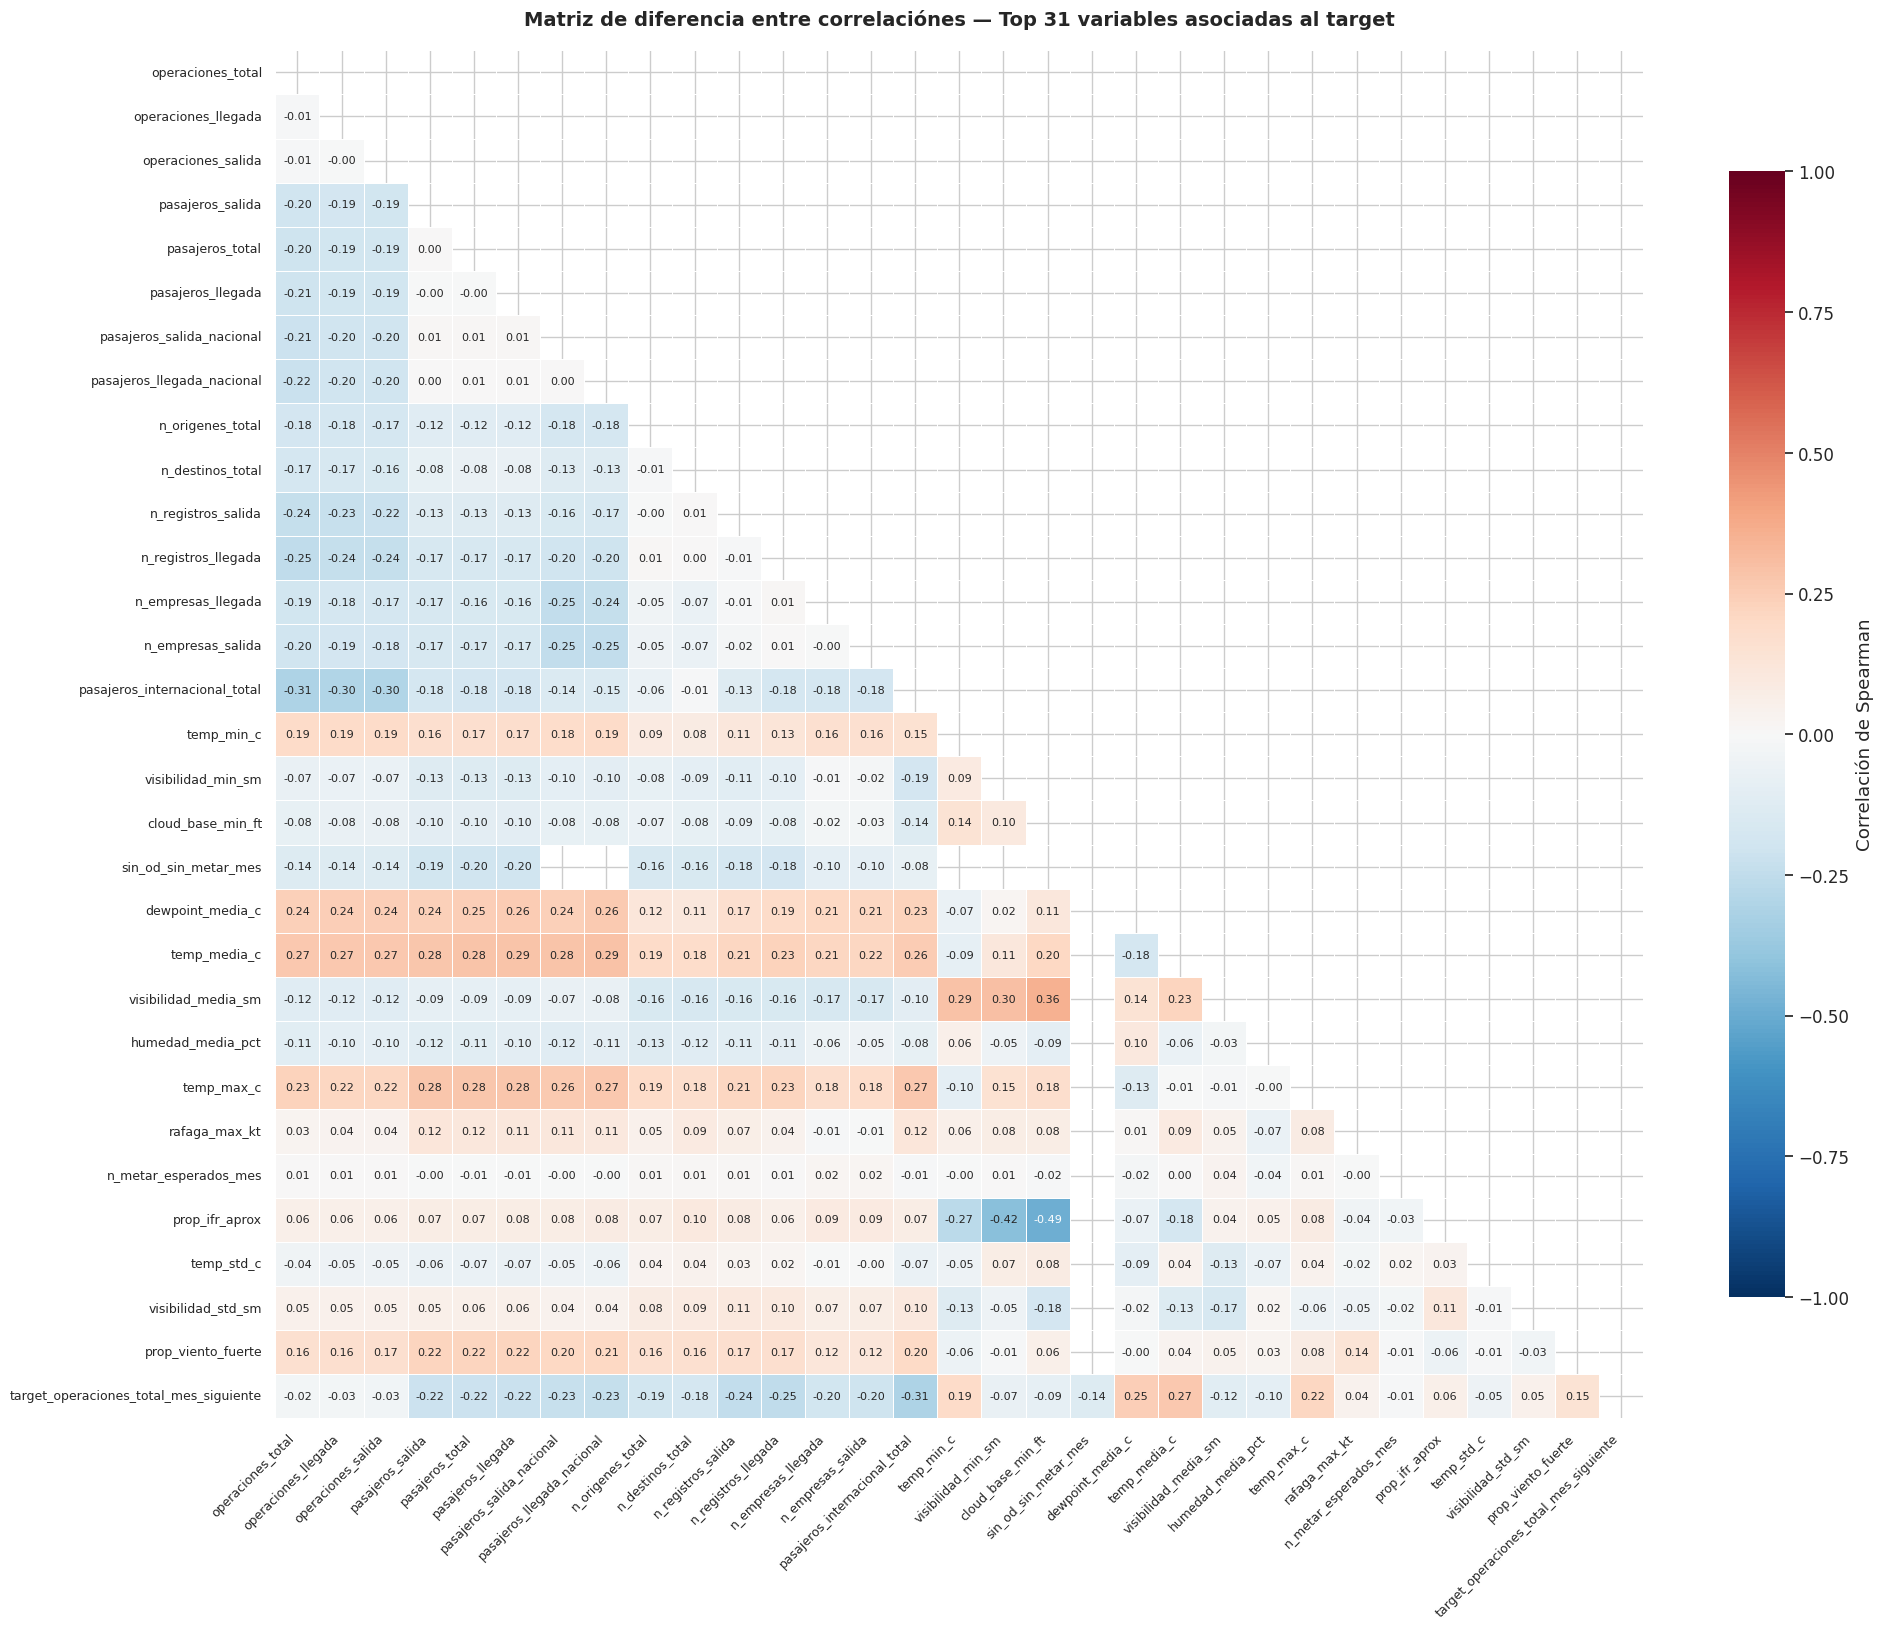

In [47]:
diff = corr_matrix_spearman - corr_matrix_pearson


figsize_base = max(10, len(cols_heatmap) * 0.65)

fig, ax = plt.subplots(figsize=(figsize_base, figsize_base * 0.85))

mask = np.triu(
    np.ones_like(diff, dtype=bool)
)

sns.heatmap(
    diff, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, ax=ax,
    linewidths=0.5, linecolor="white", square=True,
    cbar_kws={
        "shrink": 0.75,
        "label": "Correlación de Spearman",
    },
    annot_kws={
        "size": 8,
    },
)

ax.set_title(
    f"Matriz de diferencia entre correlaciónes — Top {top_n} variables asociadas al target",
    fontweight="bold",
    fontsize=14, pad=18,
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45, ha="right", fontsize=9,
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0, fontsize=9,
)

plt.tight_layout()
plt.show()